# Compare annotation performance

In [ ]:
import os.path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
import os
from pathlib import Path
from anndata.compat import DaskArray
import dask.array as da
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE
from pathlib import Path

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [4]:
models_path = Path("/g/stegle/aalsayah/repos/liana-py/inflow_score_different_annotation/models")

In [5]:
model_jst = mfl.MOFAFLEX.load(models_path / "model_jst")

In [6]:
model_lv1 = mfl.MOFAFLEX.load(models_path / "model_level1")

In [7]:
model_lv2 = mfl.MOFAFLEX.load(models_path / "model_level2")

In [ ]:
model_ist = mfl.MOFAFLEX.load(models_path / "model_ist")

In [ ]:
data_path = Path("/g/stegle/aalsayah/repos/liana-py/inflow_score_different_annotation")

In [ ]:
lrdata = sc.read_h5ad(data_path/ "inflow_score_ist.h5ad")

In [185]:
lv1 = lrdata.obs["lv1"]

In [186]:
lv2 = lrdata.obs["lv2"]

In [187]:
ist = lrdata.obs["ist"]

In [188]:
typ = lrdata.obs["typ"]

# Cluster by factor score

In [88]:
factors = model_ist.get_factors()

In [89]:
factors = factors["group_1"]

In [90]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_154_37,0.085426,0.134153,0.951666,-0.497316,-0.908589,-0.374591,-0.036147,-0.632263,0.179662,-0.087831,-0.317096,-0.290400,-0.670909,1.052463,-0.250754
c_3_154_43,0.302522,-0.037855,0.501170,-0.022138,-0.543980,0.097037,-0.099786,-0.351762,0.008662,1.159221,-0.241143,0.153900,-0.198234,0.412840,0.055381
c_3_154_61,-0.178582,-0.472574,0.582427,-0.283238,-0.009777,0.253981,-0.307251,-0.313131,0.294228,0.738428,0.273614,-0.370328,-0.259083,-0.293352,0.146010
c_3_154_69,-0.112379,-0.095783,-0.310092,0.297999,-0.333418,-0.149187,-0.224769,-0.034862,0.064551,0.672257,0.390976,-0.094665,0.313243,-0.067890,0.682875
c_3_154_75,-0.106441,0.214625,-0.231379,-0.212068,-0.355736,-0.345462,-0.624809,0.272327,0.323879,0.334184,0.059619,0.217701,0.450128,-0.164670,0.732304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_163_214,0.684093,-0.017714,0.160284,-0.627853,-0.033214,-0.165567,-0.473106,0.214921,-0.229451,-0.405425,-0.873117,0.506321,-0.227506,0.103612,0.684636
c_3_163_1843,-0.731374,-0.928795,1.742167,-0.319425,-0.465075,0.914405,1.006776,-1.343212,-0.962664,0.106438,1.183348,1.612215,0.053374,0.464126,-0.404423
c_3_163_2575,0.756079,-0.996664,-0.594713,-0.554859,-0.038884,-0.083340,0.220243,0.441358,-1.049753,-0.408831,-0.202613,0.400399,-0.462341,-0.193502,-0.109384
c_3_164_158,-0.895086,-0.670308,-0.687510,0.233258,1.254605,0.189812,0.107237,-1.204187,0.059344,-0.171521,0.116399,-0.873648,-0.580078,-0.764911,0.933357


## Metadata

In [91]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(20377,)

In [92]:
lv2 = lv2.loc[lv2.index.intersection(factors.index)]
lv2 = lv2.reindex(factors.index)
lv2.shape

(20377,)

In [93]:
typ = lrdata.obs["ctx"]
typ = typ.loc[typ.index.intersection(factors.index)]
typ = typ.reindex(factors.index)
typ.shape

(20377,)

# PCA

In [109]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming df is your factors dataframe
df = factors.copy()

# Step 1: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Step 2: Apply PCA
pca = PCA(n_components=2)   # reduce to 2D (can change to 3 for 3D plotting)
pca_result = pca.fit_transform(scaled_data)

# Create a new dataframe with reduced dimensions
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=df.index)
df_pca['Label'] = lv1.loc[df.index].values  # align by index


print(df_pca.head())

# Step 3: Explained variance ratio (how much info each component keeps)
print("Explained variance ratio:", pca.explained_variance_ratio_)


                 PC1       PC2 Label
c_3_154_37  1.083637 -1.470971   imm
c_3_154_43  0.842238 -0.199451   epi
c_3_154_61  0.011538 -0.250772   epi
c_3_154_69  0.277926  1.024771   epi
c_3_154_75  0.234706  1.192691   epi
Explained variance ratio: [0.11280314 0.09913387]


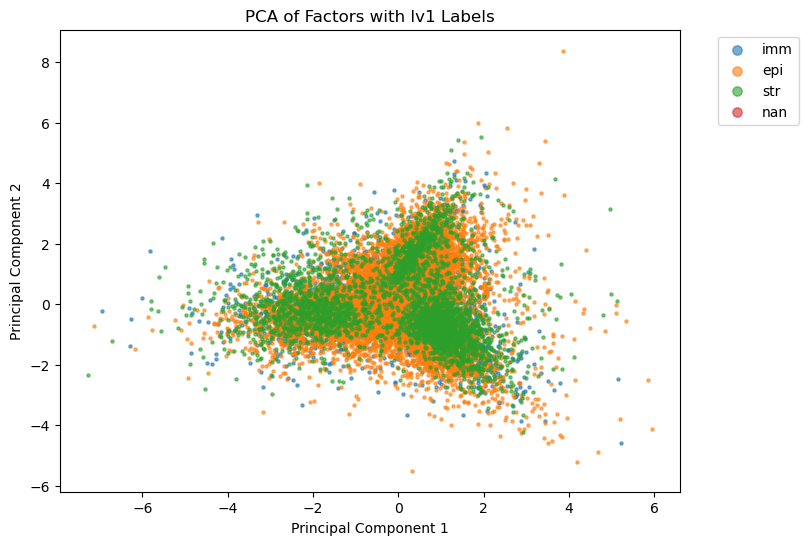

In [111]:
# Step 4: Plot with labels
plt.figure(figsize=(8,6))
for label in df_pca['Label'].unique():
    subset = df_pca[df_pca['Label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], s=5, alpha=0.6, label=label)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# UMAP

In [94]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Standardize factors
scaler = StandardScaler()
scaled_data = scaler.fit_transform(factors)

# Step 2: Apply UMAP (2D)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = reducer.fit_transform(scaled_data)

# Step 3: Put into dataframe with labels
df_umap = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'], index=factors.index)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


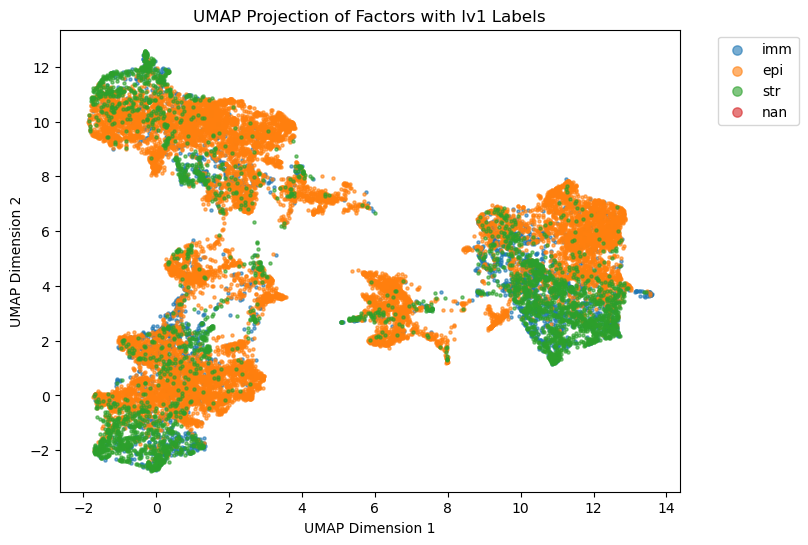

In [95]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [96]:
import hdbscan

X_umap = df_umap[['UMAP1','UMAP2']].values
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
df_umap['Cluster'] = clusterer.fit_predict(X_umap)


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


In [97]:
pd.crosstab(df_umap['Cluster'], df_umap['Label'])

Label,epi,imm,str
Cluster,,,
-1,53,23,15
0,4742,639,767
1,4310,976,1119
2,1345,72,111
3,17,41,16
4,136,10,0
5,2876,1360,1475


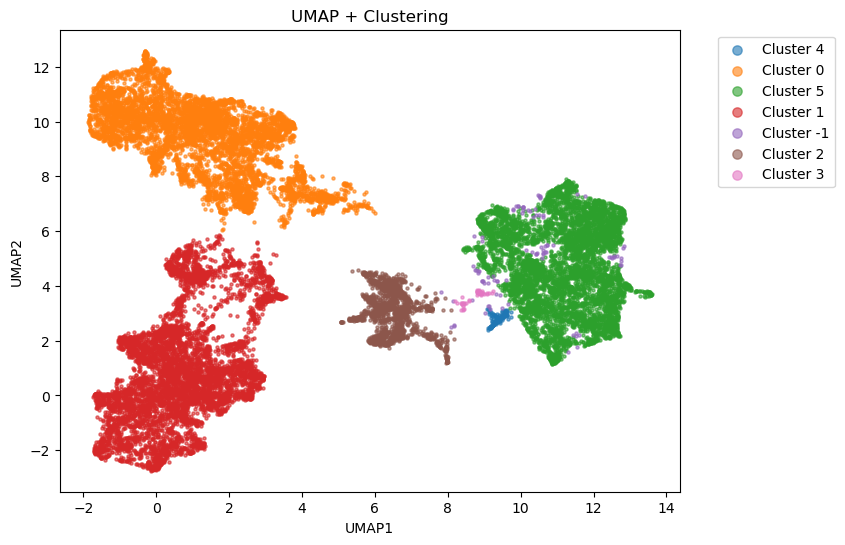

In [98]:

plt.figure(figsize=(8,6))
for cl in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == cl]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=f"Cluster {cl}")

plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

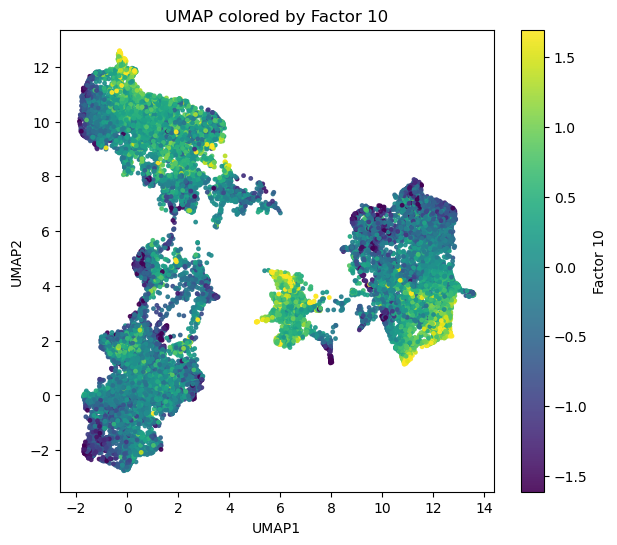

In [57]:
factor_name = "Factor 10"   # <- pick any column from `factors`

vals = factors.loc[df_umap.index, factor_name]           # align by index
vals = vals.astype(float)                                # make sure it's numeric
# (optional) clip extreme values so the color scale isn't dominated by outliers
vmin, vmax = np.percentile(vals.dropna(), [1, 99])

plt.figure(figsize=(7,6))
sc = plt.scatter(df_umap["UMAP1"], df_umap["UMAP2"],
                 c=vals, s=6, alpha=0.9, cmap="viridis",
                 vmin=vmin, vmax=vmax)
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.title(f"UMAP colored by {factor_name}")
cbar = plt.colorbar(sc)
cbar.set_label(factor_name)
plt.show()

In [58]:
# Add cluster info
factors["Cluster"] = df_umap["Cluster"]

In [26]:
# Step 1: Find factor enrichment per cluster
cluster_means = factors.groupby("Cluster").mean()

In [27]:
cluster_means

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
Cluster,,,,,,,,,,,,,,,
-1,-0.091178,-0.055508,0.149004,0.438308,-0.227071,-0.268609,0.231552,0.184402,0.334433,-0.209553,0.113218,-0.538024,-0.288993,0.238336,-0.494780
0,-0.106616,0.025526,0.237074,0.316362,-0.213202,-0.064413,-0.262400,0.151634,-0.214022,0.187152,0.139213,0.451932,0.392839,-0.035824,0.258348
1,0.185427,-0.176885,-0.488241,-0.416028,0.331071,0.334103,-0.087382,-0.233413,-0.195219,-0.183756,-0.250034,-0.124572,-0.086859,-0.219564,0.121981
2,0.314848,0.974129,-0.048339,0.244318,-0.471213,0.263270,0.349483,-0.175765,0.804108,0.603374,-0.729843,0.080929,-0.336596,-0.400143,-0.245610
3,0.494274,0.629518,0.323841,0.735278,0.185693,-0.143229,-0.430290,-0.289565,0.239895,0.198911,-0.402749,-0.806870,0.173663,0.154213,-0.330388
4,0.574890,-0.443117,0.843799,-0.630647,-0.735390,-0.277875,0.471665,-0.782702,0.410662,-0.325368,-0.307704,0.064996,-0.352682,1.186690,-0.443610
5,-0.228916,0.141612,0.171586,-0.029182,-0.132190,-0.291717,0.137535,0.065235,0.382440,-0.013723,0.246749,-0.303189,-0.291297,0.336310,-0.359625


/scratch/jobs/37128698/ipykernel_196564/2712577829.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


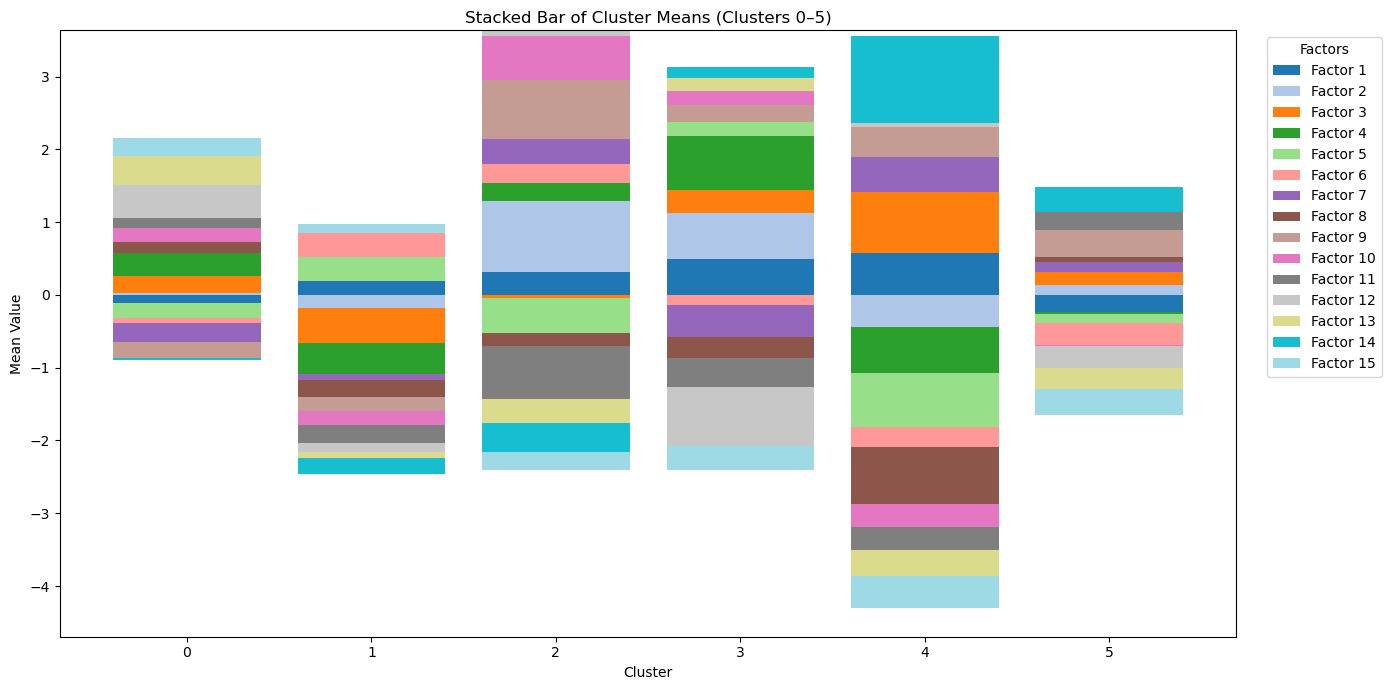

In [35]:
import matplotlib.cm as cm

# Keep only clusters 0–5 (drop -1 or others)
df = cluster_means.loc[[0, 1, 2, 3, 4, 5]]

# --- Separate positive and negative contributions ---
pos = df.clip(lower=0)
neg = df.clip(upper=0)

pos_cum = pos.cumsum(axis=1)
neg_cum = neg.cumsum(axis=1)

# --- Generate distinct colors per factor ---
num_factors = len(df.columns)
colors = cm.get_cmap("tab20", num_factors).colors  # "tab20" gives 20 distinct, cycles if >20
factor_colors = {col: colors[i] for i, col in enumerate(df.columns)}

fig, ax = plt.subplots(figsize=(14, 7))

# stack positives
for col in df.columns:
    ax.bar(
        df.index,
        pos[col],
        bottom=(pos_cum[col] - pos[col]),
        color=factor_colors[col],
        label=col
    )

# stack negatives
for col in df.columns:
    ax.bar(
        df.index,
        neg[col],
        bottom=(neg_cum[col] - neg[col]),
        color=factor_colors[col]
    )

ax.set_title("Stacked Bar of Cluster Means (Clusters 0–5)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean Value")
ax.legend(title="Factors", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## DR in cluster 0

In [140]:
factors["Cluster"] = df_umap["Cluster"]

In [177]:
df_cluster = factors[factors["Cluster"] == 5]

In [178]:
df_cluster = df_cluster.drop(columns=["Cluster"])

In [179]:
df_cluster

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_154_93,-0.423009,-0.114959,-0.091516,0.208034,-0.331646,-0.288080,0.134029,-0.526484,0.268330,0.187153,0.395191,-0.402129,-0.276235,0.253240,0.053263
c_3_154_101,-0.411698,-0.048132,-0.370864,0.124502,0.233710,0.102120,-0.316489,-0.237316,-0.033158,-0.224759,-0.074437,-0.831881,-0.217083,0.014377,-0.258089
c_3_154_109,-0.279822,0.129249,0.185285,-0.272334,-0.202933,0.333123,-0.385276,-0.172669,0.572078,0.294788,0.035152,-0.605438,-0.420678,0.067939,0.118483
c_3_154_124,-0.387398,-0.140550,-0.256225,0.518657,-0.498391,-0.016848,0.099067,-0.407698,0.147531,0.104321,0.457033,-0.696099,-0.226195,0.005532,0.055998
c_3_154_131,-0.073664,0.121553,-0.417549,0.265201,-0.344768,-0.400036,-0.011762,-0.369571,0.339192,0.027470,0.419574,-0.329397,-0.089794,0.503190,0.220983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_175_1708,-1.046090,0.049385,0.553705,-0.193970,-0.824111,-0.031871,0.007980,0.256479,0.203945,-0.330326,-0.799747,-0.681887,-0.102681,-0.294840,-0.728506
c_3_175_1772,-1.209010,0.554709,0.248196,-0.083556,-0.531053,-0.095102,-0.257570,-0.493260,0.377542,-0.075491,-0.310524,-0.731148,0.185272,-0.105936,-0.828326
c_3_179_270,-0.298959,0.319627,0.293150,-0.495535,0.167804,-0.495559,0.189162,-0.253885,0.036430,0.101155,-0.005853,0.350600,-0.430954,0.018048,-0.395450
c_3_195_361,-1.123187,1.105946,0.446371,-0.798971,0.011405,-0.571267,-0.282891,-1.693451,-0.039122,0.633864,-0.928319,-0.039804,0.047107,-0.005569,-1.481406


In [180]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Standardize factors
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

# Step 2: Apply UMAP (2D)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = reducer.fit_transform(scaled_data)

# Step 3: Put into dataframe with labels
df_umap_c0 = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'], index=df_cluster.index)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [181]:
df_umap_c0

,UMAP1,UMAP2
c_3_154_93,-1.070111,1.812766
c_3_154_101,1.805829,1.495310
c_3_154_109,0.513304,1.266933
c_3_154_124,-1.284835,1.958240
c_3_154_131,-0.608224,1.464066
...,...,...
c_3_175_1708,1.145636,5.443524
c_3_175_1772,1.499262,4.921142
c_3_179_270,5.044740,2.471551
c_3_195_361,5.737814,2.769834


In [189]:
lv1 = lv1.loc[lv1.index.intersection(df_cluster.index)]
lv1 = lv1.reindex(df_cluster.index)
lv1.shape

(5801,)

In [190]:
ist = ist.loc[ist.index.intersection(df_cluster.index)]
ist = ist.reindex(df_cluster.index)
ist.shape

(5801,)

In [191]:
typ = typ.loc[typ.index.intersection(df_cluster.index)]
typ = typ.reindex(df_cluster.index)
typ.shape

(5801,)

In [196]:
df_umap_c0['Label'] = ist.loc[df_cluster.index].values

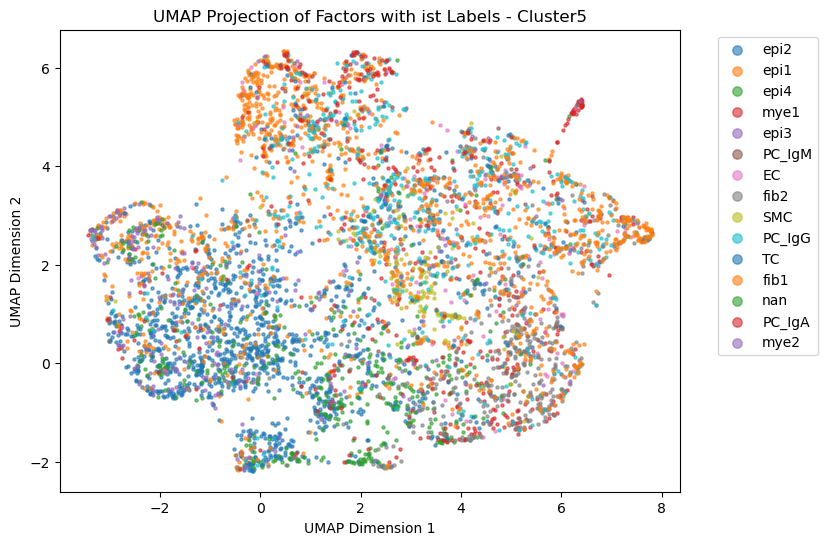

In [197]:
# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap_c0['Label'].unique():
    subset = df_umap_c0[df_umap_c0['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with ist Labels - Cluster5")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Loading Weights 

In [225]:
top_factors

Index(['Factor 9', 'Factor 15', 'Factor 14'], dtype='object')

In [231]:
top_genes_per_cluster = {}

for cl in cluster_means.index:
    # rank factors by absolute enrichment
    ranked_factors = cluster_means.loc[cl].drop("Cluster", errors="ignore").sort_values(
        key=np.abs, ascending=False
    )
    top_factors = ranked_factors.index[:3]  # top 3 strongest factors
    
    cluster_genes = {}
    for f in top_factors:
        cluster_genes[f] = {}
        # go through each view
        for view, w in model_ist.get_weights().items():
            gene_weights = w.loc[f].sort_values(
                key=np.abs, ascending=False
            )
            cluster_genes[f][view] = gene_weights.head(30)  # top 30 genes
    top_genes_per_cluster[cl] = cluster_genes


In [234]:
 model_ist.get_weights().items()

dict_items([('EC',            EC^CEACAM1^CEACAM5  EC^MDK^NCL  EC^APP^CD74  EC^PDGFA^PDGFRB  \
Factor 1             0.000787    0.012454     0.215195         0.012229   
Factor 2             0.002108   -0.003136    -0.050894        -0.011238   
Factor 3            -0.004199   -0.028130     0.090651         0.003401   
Factor 4            -0.003222   -0.000170    -0.062682         0.000970   
Factor 5            -0.008009   -0.039196    -0.166701        -0.001431   
Factor 6             0.008040    0.004715     0.019260        -0.007806   
Factor 7            -0.001425    0.008479     0.141293         0.013601   
Factor 8             0.006539    0.035531     0.184246         0.017374   
Factor 9             0.002488   -0.012392    -0.124671        -0.016246   
Factor 10            0.006109    0.030354     0.060723         0.013177   
Factor 11           -0.015523   -0.066661    -0.186521        -0.006120   
Factor 12           -0.000723   -0.011261    -0.104167        -0.016960   
Factor

In [232]:
cluster_genes

{'Factor 9': {'EC': EC^COL1A1^SDC4   -1.297660
  EC^COL1A1^SDC1   -0.949313
  EC^COL4A1^SDC4   -0.794052
  EC^COL4A1^SDC1   -0.733924
  EC^COL4A2^SDC4   -0.602770
  EC^COL4A2^SDC1   -0.598538
  EC^FN1^SDC4      -0.580152
  EC^FN1^SDC1      -0.432382
  EC^COL1A2^SDC1   -0.423238
  EC^COL1A2^SDC4   -0.390899
  EC^COL6A2^SDC4   -0.323404
  EC^COL6A2^SDC1   -0.305590
  EC^COL6A1^SDC4   -0.231844
  EC^THBS1^SDC4    -0.218452
  EC^COL6A1^SDC1   -0.193114
  EC^COL6A3^SDC1   -0.139604
  EC^MDK^SDC4      -0.130895
  EC^COL1A1^CD44   -0.126134
  EC^APP^CD74      -0.124671
  EC^COL6A3^SDC4   -0.123207
  EC^THBS1^CD47     0.116527
  EC^TNC^SDC4      -0.086485
  EC^THBS1^SDC1    -0.076132
  EC^LAMA4^CD44     0.060634
  EC^THBS2^SDC4    -0.056616
  EC^MDK^SDC1      -0.050846
  EC^LAMB1^CD44     0.049296
  EC^THBS2^CD47     0.048830
  EC^COL6A3^CD44    0.046804
  EC^LGALS9^CD44   -0.035919
  Name: Factor 9, dtype: float32,
  'PC_IgA': PC_IgA^COL6A2^SDC1   -0.786500
  PC_IgA^COL1A1^CD44    0.770554
  

In [222]:
cluster_genes

{'Factor 9': {'EC': EC^COL1A1^SDC4       -1.297660
  EC^COL1A1^SDC1       -0.949313
  EC^COL4A1^SDC4       -0.794052
  EC^COL4A1^SDC1       -0.733924
  EC^COL4A2^SDC4       -0.602770
  EC^COL4A2^SDC1       -0.598538
  EC^FN1^SDC4          -0.580152
  EC^FN1^SDC1          -0.432382
  EC^COL1A2^SDC1       -0.423238
  EC^COL1A2^SDC4       -0.390899
  EC^COL6A2^SDC4       -0.323404
  EC^COL6A2^SDC1       -0.305590
  EC^COL6A1^SDC4       -0.231844
  EC^THBS1^SDC4        -0.218452
  EC^COL6A1^SDC1       -0.193114
  EC^COL6A3^SDC1       -0.139604
  EC^MDK^SDC4          -0.130895
  EC^COL1A1^CD44       -0.126134
  EC^APP^CD74          -0.124671
  EC^COL6A3^SDC4       -0.123207
  EC^THBS1^CD47         0.116527
  EC^TNC^SDC4          -0.086485
  EC^THBS1^SDC1        -0.076132
  EC^LAMA4^CD44         0.060634
  EC^THBS2^SDC4        -0.056616
  EC^MDK^SDC1          -0.050846
  EC^LAMB1^CD44         0.049296
  EC^THBS2^CD47         0.048830
  EC^COL6A3^CD44        0.046804
  EC^LGALS9^CD44       -0

In [221]:
top_genes_per_cluster

{-1: {'Factor 12': {'EC': EC^COL1A1^SDC4        1.052549
   EC^COL1A1^CD44       -0.843531
   EC^COL4A1^SDC4        0.778467
   EC^COL4A1^CD44       -0.679908
   EC^COL4A2^SDC4        0.555662
   EC^COL4A2^CD44       -0.529167
   EC^FN1^SDC4           0.477340
   EC^COL1A2^SDC4        0.395569
   EC^FN1^CD44          -0.375095
   EC^COL4A1^SDC1       -0.375057
   EC^COL1A1^SDC1       -0.366960
   EC^COL4A2^SDC1       -0.339250
   EC^COL6A2^CD44       -0.295951
   EC^LAMA4^CD44        -0.280431
   EC^COL6A2^SDC4        0.267175
   EC^COL1A2^CD44       -0.256188
   EC^LGALS9^CD44       -0.233973
   EC^COL6A1^SDC4        0.231002
   EC^COL6A1^CD44       -0.204080
   EC^THBS1^SDC4         0.192860
   EC^FN1^SDC1          -0.178717
   EC^COL1A2^SDC1       -0.170283
   EC^COL6A3^SDC4        0.149637
   EC^COL6A2^SDC1       -0.142638
   EC^LAMB1^CD44        -0.139363
   EC^COL6A1^SDC1       -0.133654
   EC^COL6A3^CD44       -0.128253
   EC^MDK^SDC4           0.117882
   EC^APP^CD74          -

In [211]:
rows = []

for cl, factor_dict in top_genes_per_cluster.items():
    for f, view_dict in factor_dict.items():
        for view, genes in view_dict.items():
            # take the single top gene (highest weight)
            top_gene = genes.index[0]
            top_weight = genes.iloc[0]
            rows.append({
                "Cluster": cl,
                "View": view,
                "Factor": f,
                "TopGene": top_gene,
                "Weight": top_weight
            })

df_top = pd.DataFrame(rows)

In [214]:
df_top[df_top["Cluster"] == 3]

,Cluster,View,Factor,TopGene,Weight
144,3,EC,Factor 12,EC^COL1A1^SDC4,1.052549
145,3,PC_IgA,Factor 12,PC_IgA^COL1A1^SDC1,-1.144801
146,3,PC_IgG,Factor 12,PC_IgG^COL1A1^SDC1,-0.914478
147,3,SMC,Factor 12,SMC^FN1^SDC4,1.620048
148,3,TC,Factor 12,TC^COL1A1^SDC1,-1.219894
149,3,epi1,Factor 12,epi1^LGALS9^CD44,-1.627279
150,3,epi2,Factor 12,epi2^MDK^SDC4,0.712090
151,3,epi3,Factor 12,epi3^THBS1^SDC4,0.606274
152,3,epi4,Factor 12,epi4^MDK^SDC4,1.141010
153,3,fib1,Factor 12,fib1^COL1A1^SDC4,0.434965


In [202]:
df_top_sorted = df_top.sort_values("Weight", ascending=False)

df_top_sorted.style.set_table_attributes(
    'style="display:inline;overflow:auto;height:300px;width:800px;"'
).set_table_styles([
    dict(selector="tbody", props=[("overflow", "auto")])
])


,Cluster,View,Factor,TopGene,Weight
94,1,fib2,Factor 5,fib2^COL1A1^CD44,2.433086
57,0,fib1,Factor 13,fib1^COL1A1^SDC1,2.401372
178,3,fib2,Factor 1,fib2^COL1A1^SDC1,2.132422
214,4,fib2,Factor 1,fib2^COL1A1^SDC1,2.132422
106,1,fib2,Factor 1,fib2^COL1A1^SDC1,2.132422
201,4,fib1,Factor 3,fib1^COL1A1^CD44,2.125598
234,5,epi2,Factor 14,epi2^MIF^CD44_CD74,1.911016
30,-1,epi2,Factor 14,epi2^MIF^CD44_CD74,1.911016
186,4,epi2,Factor 14,epi2^MIF^CD44_CD74,1.911016
141,2,fib1,Factor 10,fib1^COL1A1^SDC4,1.883132


In [32]:
weights = model_ist.get_weights()

In [77]:
weights

{'EC':            EC^CEACAM1^CEACAM5  EC^MDK^NCL  EC^APP^CD74  EC^PDGFA^PDGFRB  \
 Factor 1             0.000787    0.012454     0.215195         0.012229   
 Factor 2             0.002108   -0.003136    -0.050894        -0.011238   
 Factor 3            -0.004199   -0.028130     0.090651         0.003401   
 Factor 4            -0.003222   -0.000170    -0.062682         0.000970   
 Factor 5            -0.008009   -0.039196    -0.166701        -0.001431   
 Factor 6             0.008040    0.004715     0.019260        -0.007806   
 Factor 7            -0.001425    0.008479     0.141293         0.013601   
 Factor 8             0.006539    0.035531     0.184246         0.017374   
 Factor 9             0.002488   -0.012392    -0.124671        -0.016246   
 Factor 10            0.006109    0.030354     0.060723         0.013177   
 Factor 11           -0.015523   -0.066661    -0.186521        -0.006120   
 Factor 12           -0.000723   -0.011261    -0.104167        -0.016960   
 Facto

In [121]:
import pandas as pd
from scipy.stats import ttest_ind


In [ ]:

expr = original_expression.loc[df_umap.index]  # original gene expression
expr['Cluster'] = df_umap['Cluster']

results = {}
for cl in df_umap['Cluster'].unique():
    group = expr[expr['Cluster'] == cl].drop('Cluster', axis=1)
    rest  = expr[expr['Cluster'] != cl].drop('Cluster', axis=1)
    t_stats, p_vals = ttest_ind(group, rest, axis=0, equal_var=False)
    res = pd.DataFrame({'t_stat': t_stats, 'p_val': p_vals}, index=group.columns)
    results[cl] = res.sort_values('p_val').head(20)  # top 20 DE genes


# t-SNE

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20377 samples in 0.049s...
[t-SNE] Computed neighbors for 20377 samples in 7.818s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20377
[t-SNE] Computed conditional probabilities for sample 2000 / 20377
[t-SNE] Computed conditional probabilities for sample 3000 / 20377
[t-SNE] Computed conditional probabilities for sample 4000 / 20377
[t-SNE] Computed conditional probabilities for sample 5000 / 20377
[t-SNE] Computed conditional probabilities for sample 6000 / 20377
[t-SNE] Computed conditional probabilities for sample 7000 / 20377
[t-SNE] Computed conditional probabilities for sample 8000 / 20377
[t-SNE] Computed conditional probabilities for sample 9000 / 20377
[t-SNE] Computed conditional probabilities for sample 10000 / 20377
[t-SNE] Computed conditional probabilities for sample 11000 / 20377
[t-SNE] Computed conditional probabilities for sample 12000 / 20377
[t-SNE] Computed conditional probabilities for sam

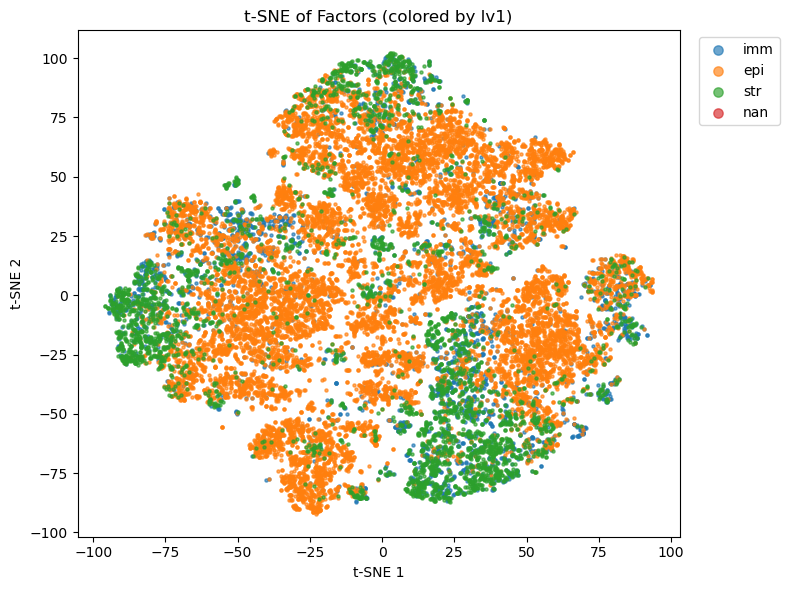

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# factors: DataFrame with 15 columns (Factor 1...Factor 15), ~20k rows
# lv1: Series/DataFrame of labels with the same index as `factors`

X = factors.astype(float).copy()

# 1) Standardize
X_std = StandardScaler().fit_transform(X)

# 2) Optional but recommended: PCA to ~30 comps (or <= original dims)
n_pca = min(30, X.shape[1])
X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X_std)

# 3) t-SNE to 2D (good defaults for ~20k rows; tweak if needed)
tsne = TSNE(
    n_components=2,
    perplexity=30,          # try 5–50; larger == more global structure
    learning_rate='auto',   # lets sklearn set a good value
    init='pca',             # stable starting point
    early_exaggeration=12,  # 8–24 is typical
    n_iter=1000,            # 750–3000; more = slower but crisper
    angle=0.5,              # Barnes–Hut speed/accuracy tradeoff (0.2–0.8)
    random_state=42,
    verbose=1
)
Y = tsne.fit_transform(X_pca)

# 4) Put in a DataFrame and align labels
emb = pd.DataFrame(Y, columns=['tSNE1','tSNE2'], index=factors.index)
emb['Label'] = lv1.loc[emb.index].values

# 5) Plot
plt.figure(figsize=(8,6))
for lbl in emb['Label'].unique():
    s = emb[emb['Label'] == lbl]
    plt.scatter(s['tSNE1'], s['tSNE2'], s=5, alpha=0.65, label=str(lbl))
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.title('t-SNE of Factors (colored by lv1)')
plt.legend(markerscale=3, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


## UMAP

In [94]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [97]:
X = factors.values
X_scaled = StandardScaler().fit_transform(X)

In [98]:
pca= PCA(n_components=10, svd_solver="arpack")
X_pca = pca.fit_transform(X_scaled)

In [103]:
pc_df = pd.DataFrame(
    X_pca[:, :2],                 # take first 2 PCs
    columns=["PC1", "PC2"],       # name them
    index=X.index if hasattr(X, "index") else None  
)
pc_df["cell_type"] = lv1.values  

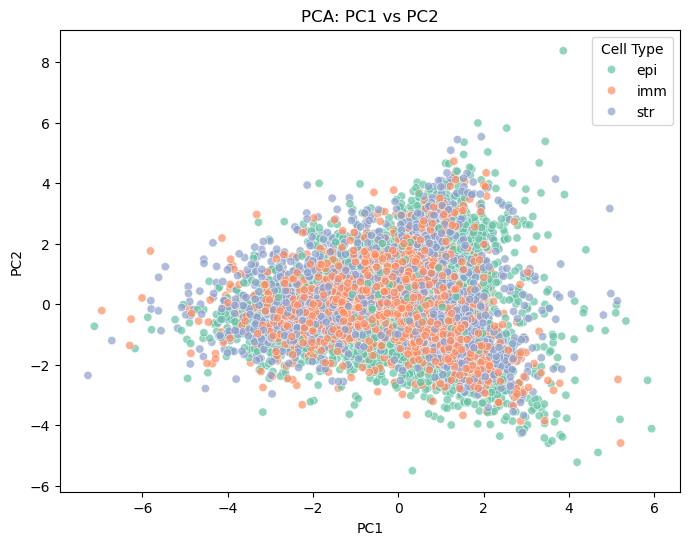

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pc_df,
    x="PC1", y="PC2",
    hue="cell_type",          # color by cell type
    palette="Set2",           # choose color palette
    alpha=0.7                 # transparency
)
plt.title("PCA: PC1 vs PC2")
plt.legend(title="Cell Type")
plt.show()


In [ ]:
import umap

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
umap_embedding = UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


### t-SNE

In [51]:
tsne_embedding = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)

## Plot

In [24]:
cell_types = lrdata.obs["typ"]
filtered_cell_types = cell_types.loc[cell_types.index.isin(F_index)]
filtered_cell_types = filtered_cell_types.reindex(factors.index)

In [31]:
lrdata.obs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129915 entries, c_3_147_1 to c_3_217_1947
Data columns (total 83 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   fov                      129915 non-null  int32   
 1   Area                     129915 non-null  int32   
 2   AspectRatio              129915 non-null  float64 
 3   CenterX_local_px         129915 non-null  int32   
 4   CenterY_local_px         129915 non-null  int32   
 5   Width                    129915 non-null  int32   
 6   Height                   129915 non-null  int32   
 7   Mean.PanCK               129915 non-null  int32   
 8   Max.PanCK                129915 non-null  int32   
 9   Mean.CD68_CK8_18         129915 non-null  int32   
 10  Max.CD68_CK8_18          129915 non-null  int32   
 11  Mean.CD298_B2M           129915 non-null  int32   
 12  Max.CD298_B2M            129915 non-null  int32   
 13  Mean.CD45                129915 non

In [149]:
F_score= factors["Factor 8"]
F_score = F_score.reindex(factors.index) 

In [22]:
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

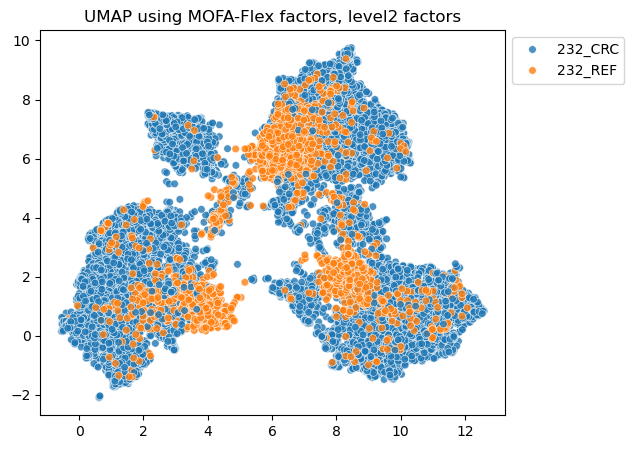

In [25]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=umap_embedding[:,0], y=umap_embedding[:,1],
                hue=filtered_cell_types, palette="tab10", s=30, alpha=0.8)
plt.title("UMAP using MOFA-Flex factors, level2 factors")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

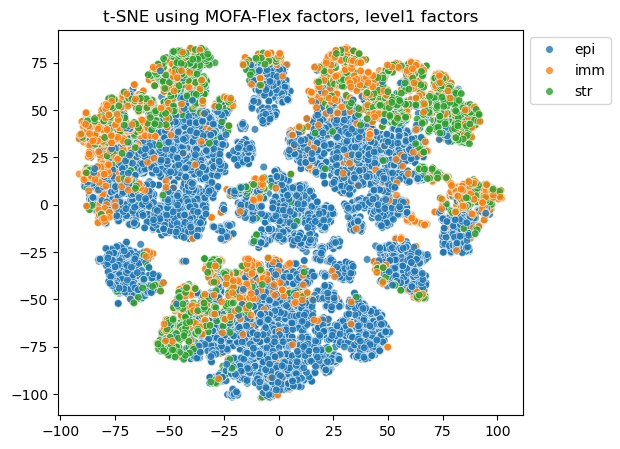

In [74]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=tsne_embedding[:,0], y=tsne_embedding[:,1],
                hue=filtered_cell_types, palette="tab10", s=30, alpha=0.8)
plt.title("t-SNE using MOFA-Flex factors, level1 factors")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

## Factor Corr

In [12]:
mfl.pl.factor_correlation(model_lv1)

ImportError: cannot import name '_atomic' from 'plotnine.mapping' (/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/mapping/__init__.py)

## Variance Explained (%) 

In [13]:
import matplotlib.pyplot as plt

In [14]:
mfl.pl.variance_explained(model_jst, figsize= (8,8))

TypeError: palette.__init__() got an unexpected keyword argument 'min_colors'

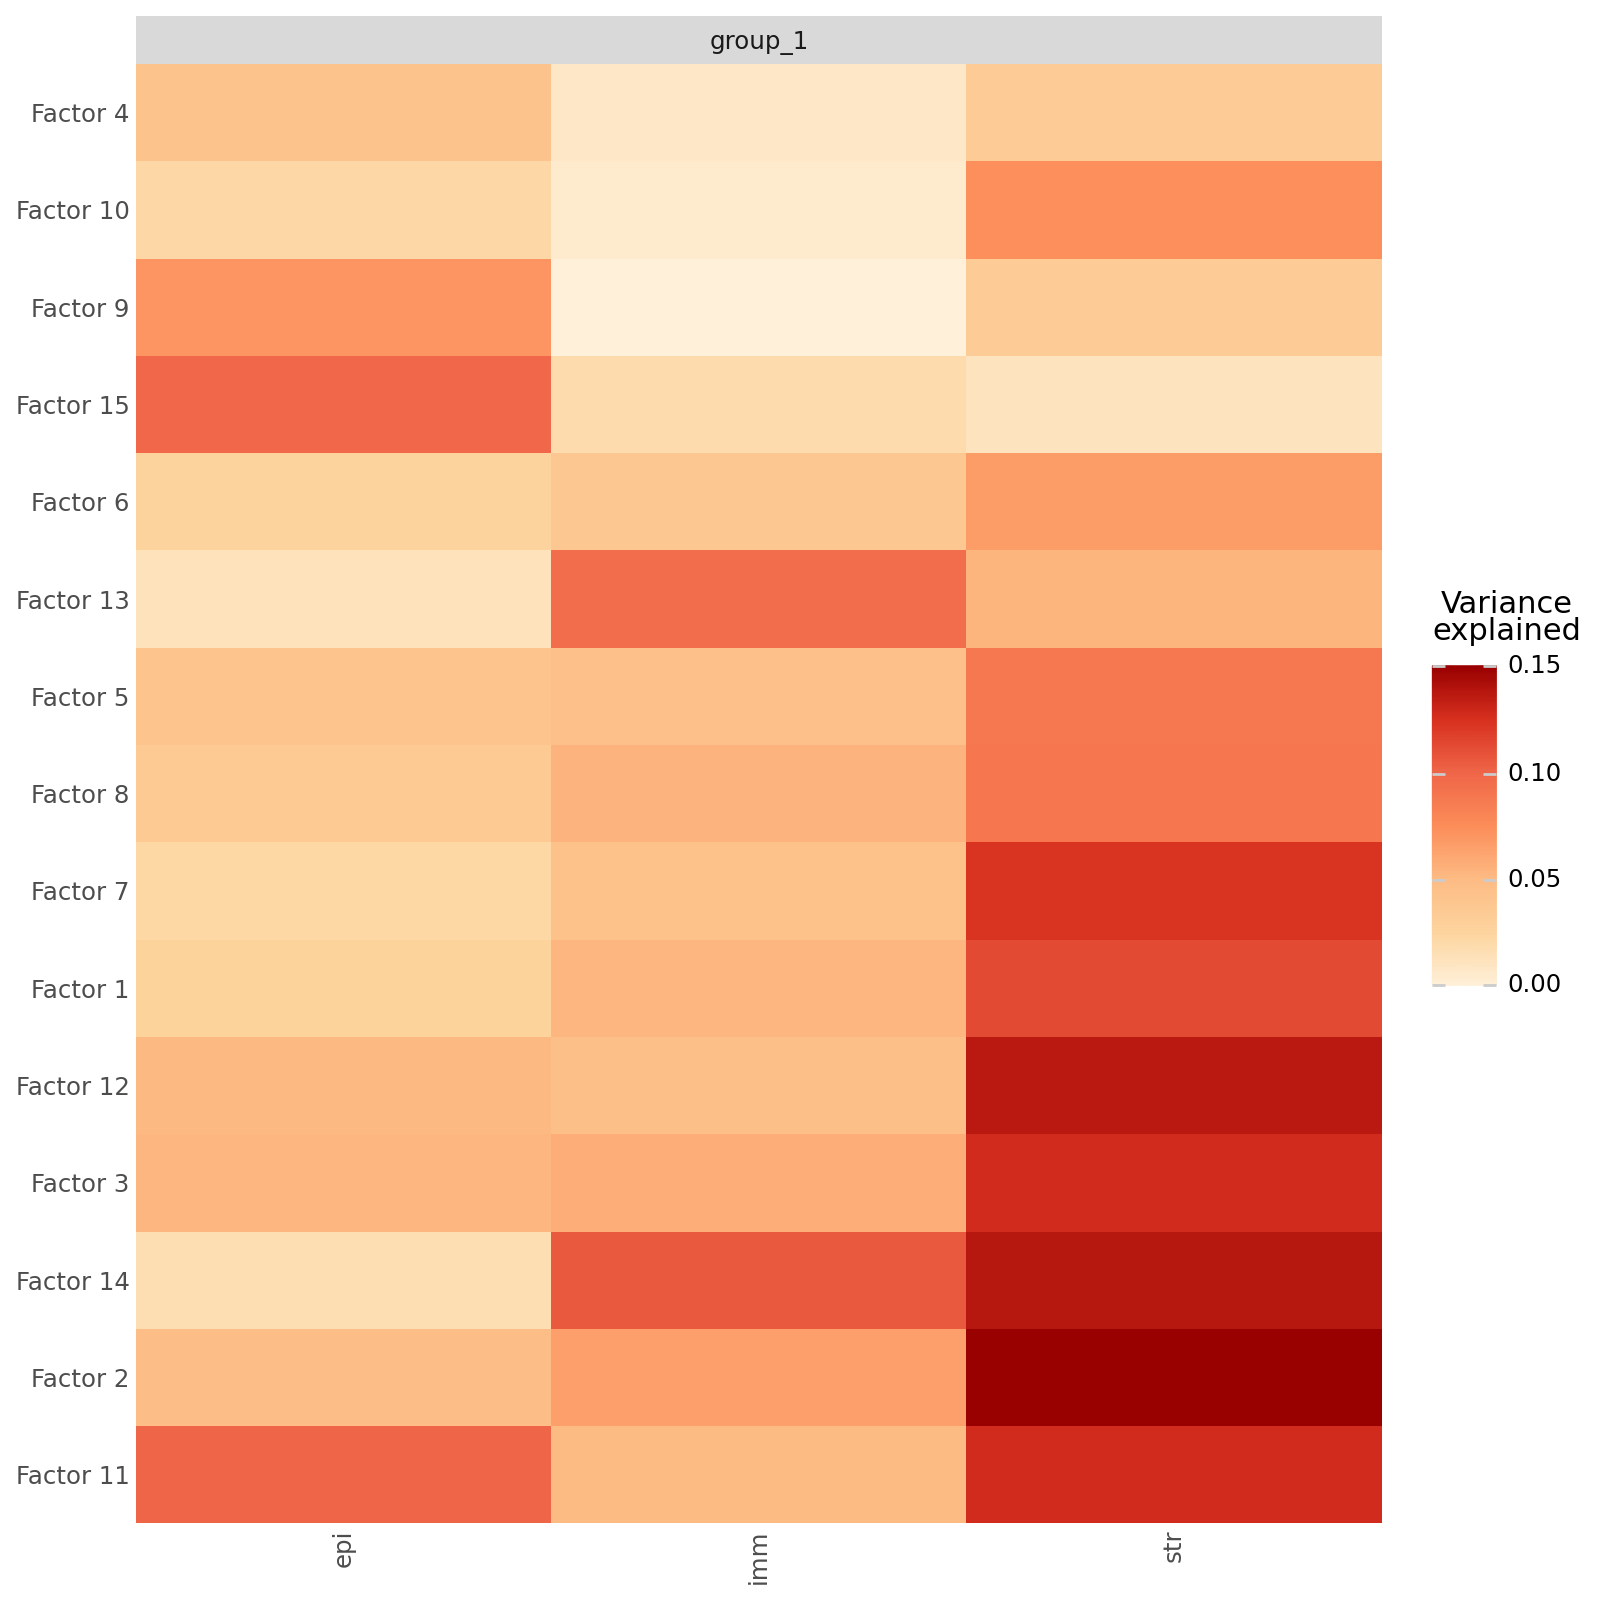

In [9]:
mfl.pl.variance_explained(model_lv1, figsize= (8,8))

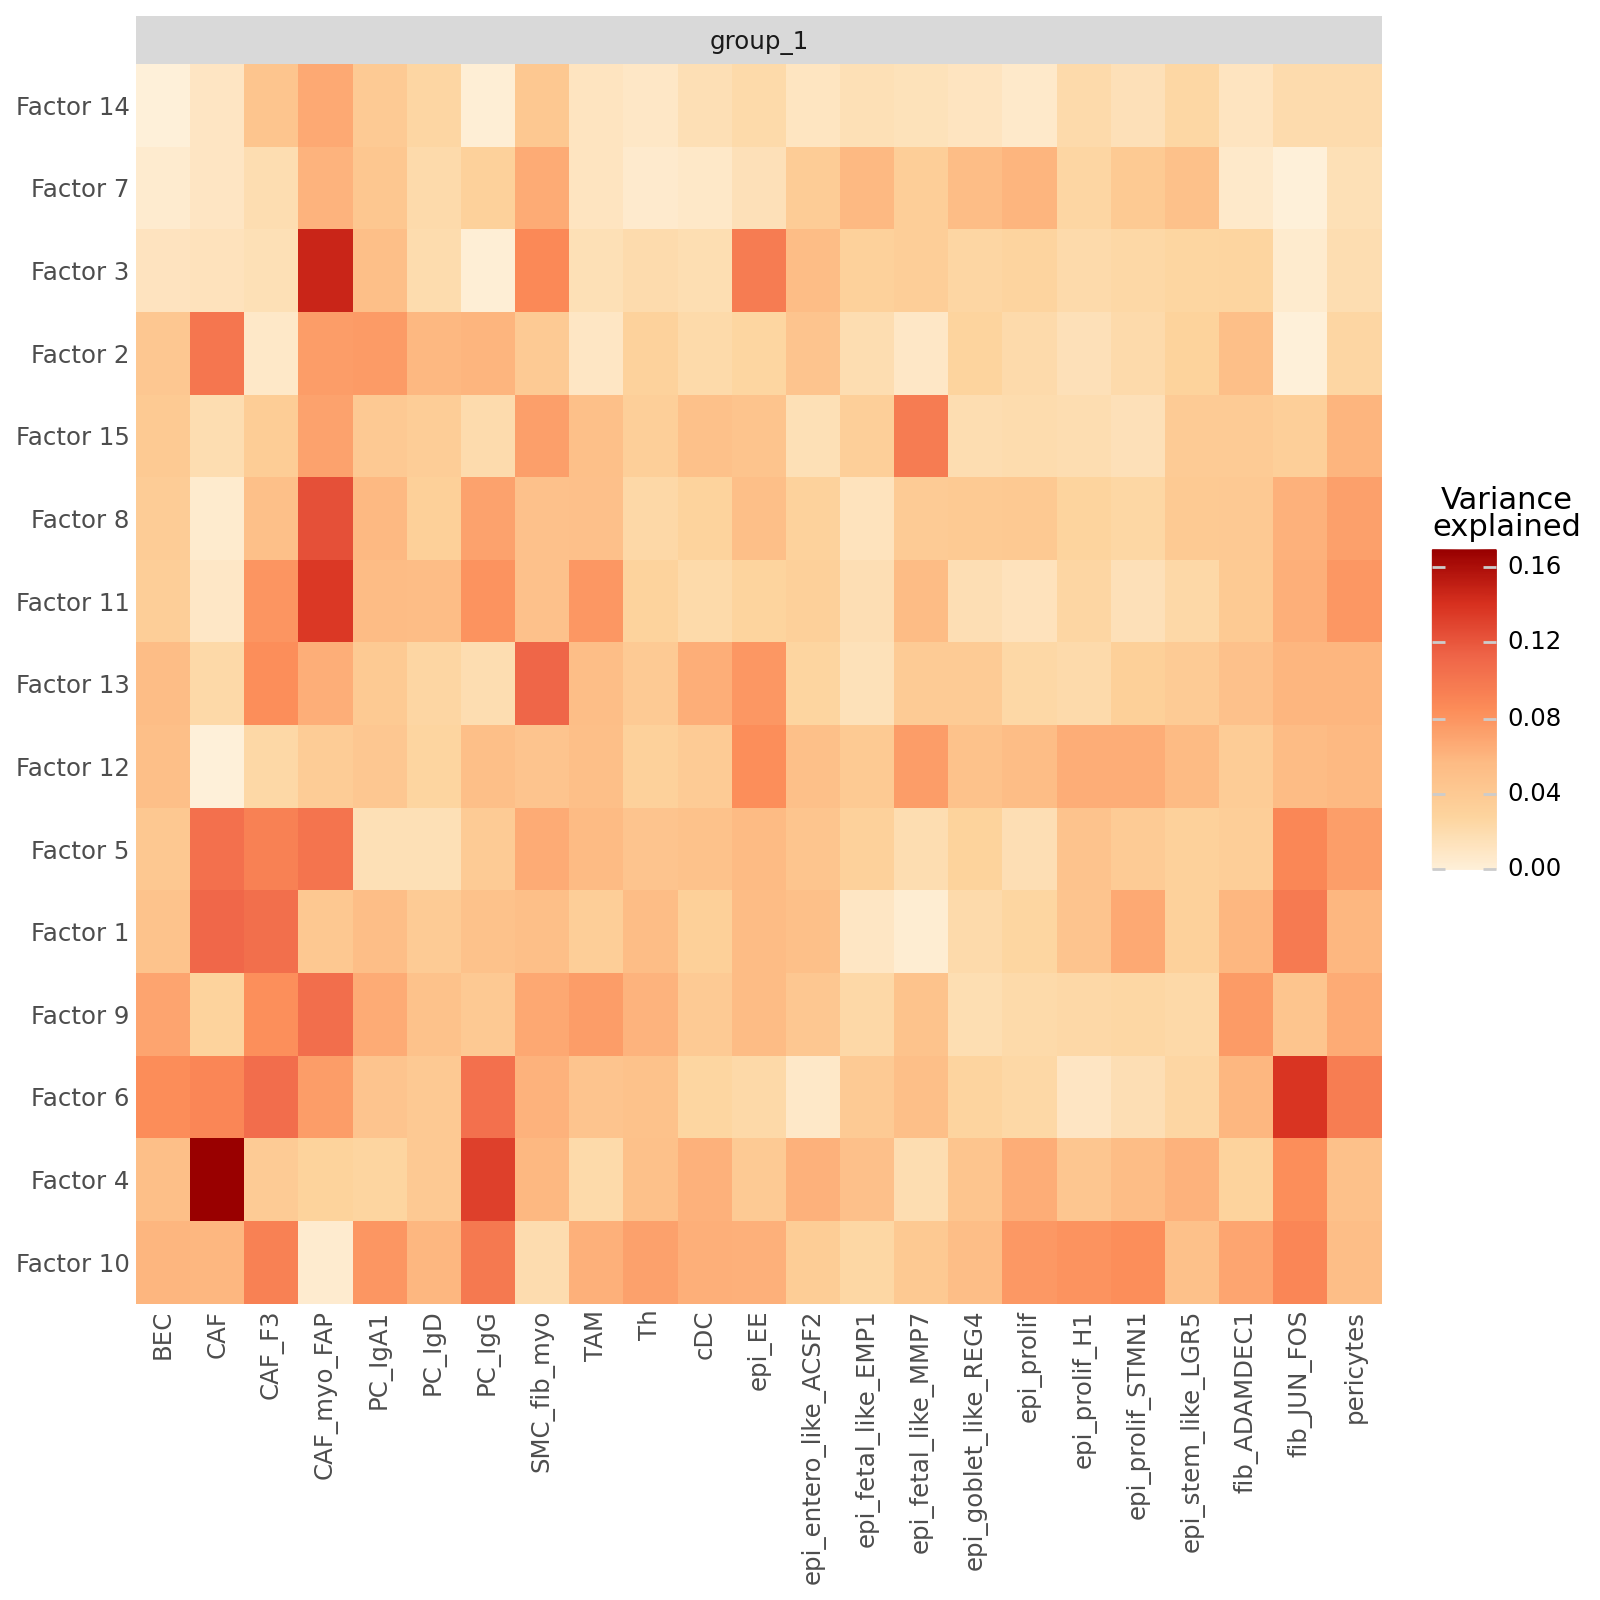

In [10]:
mfl.pl.variance_explained(model_lv2, figsize= (8,8))

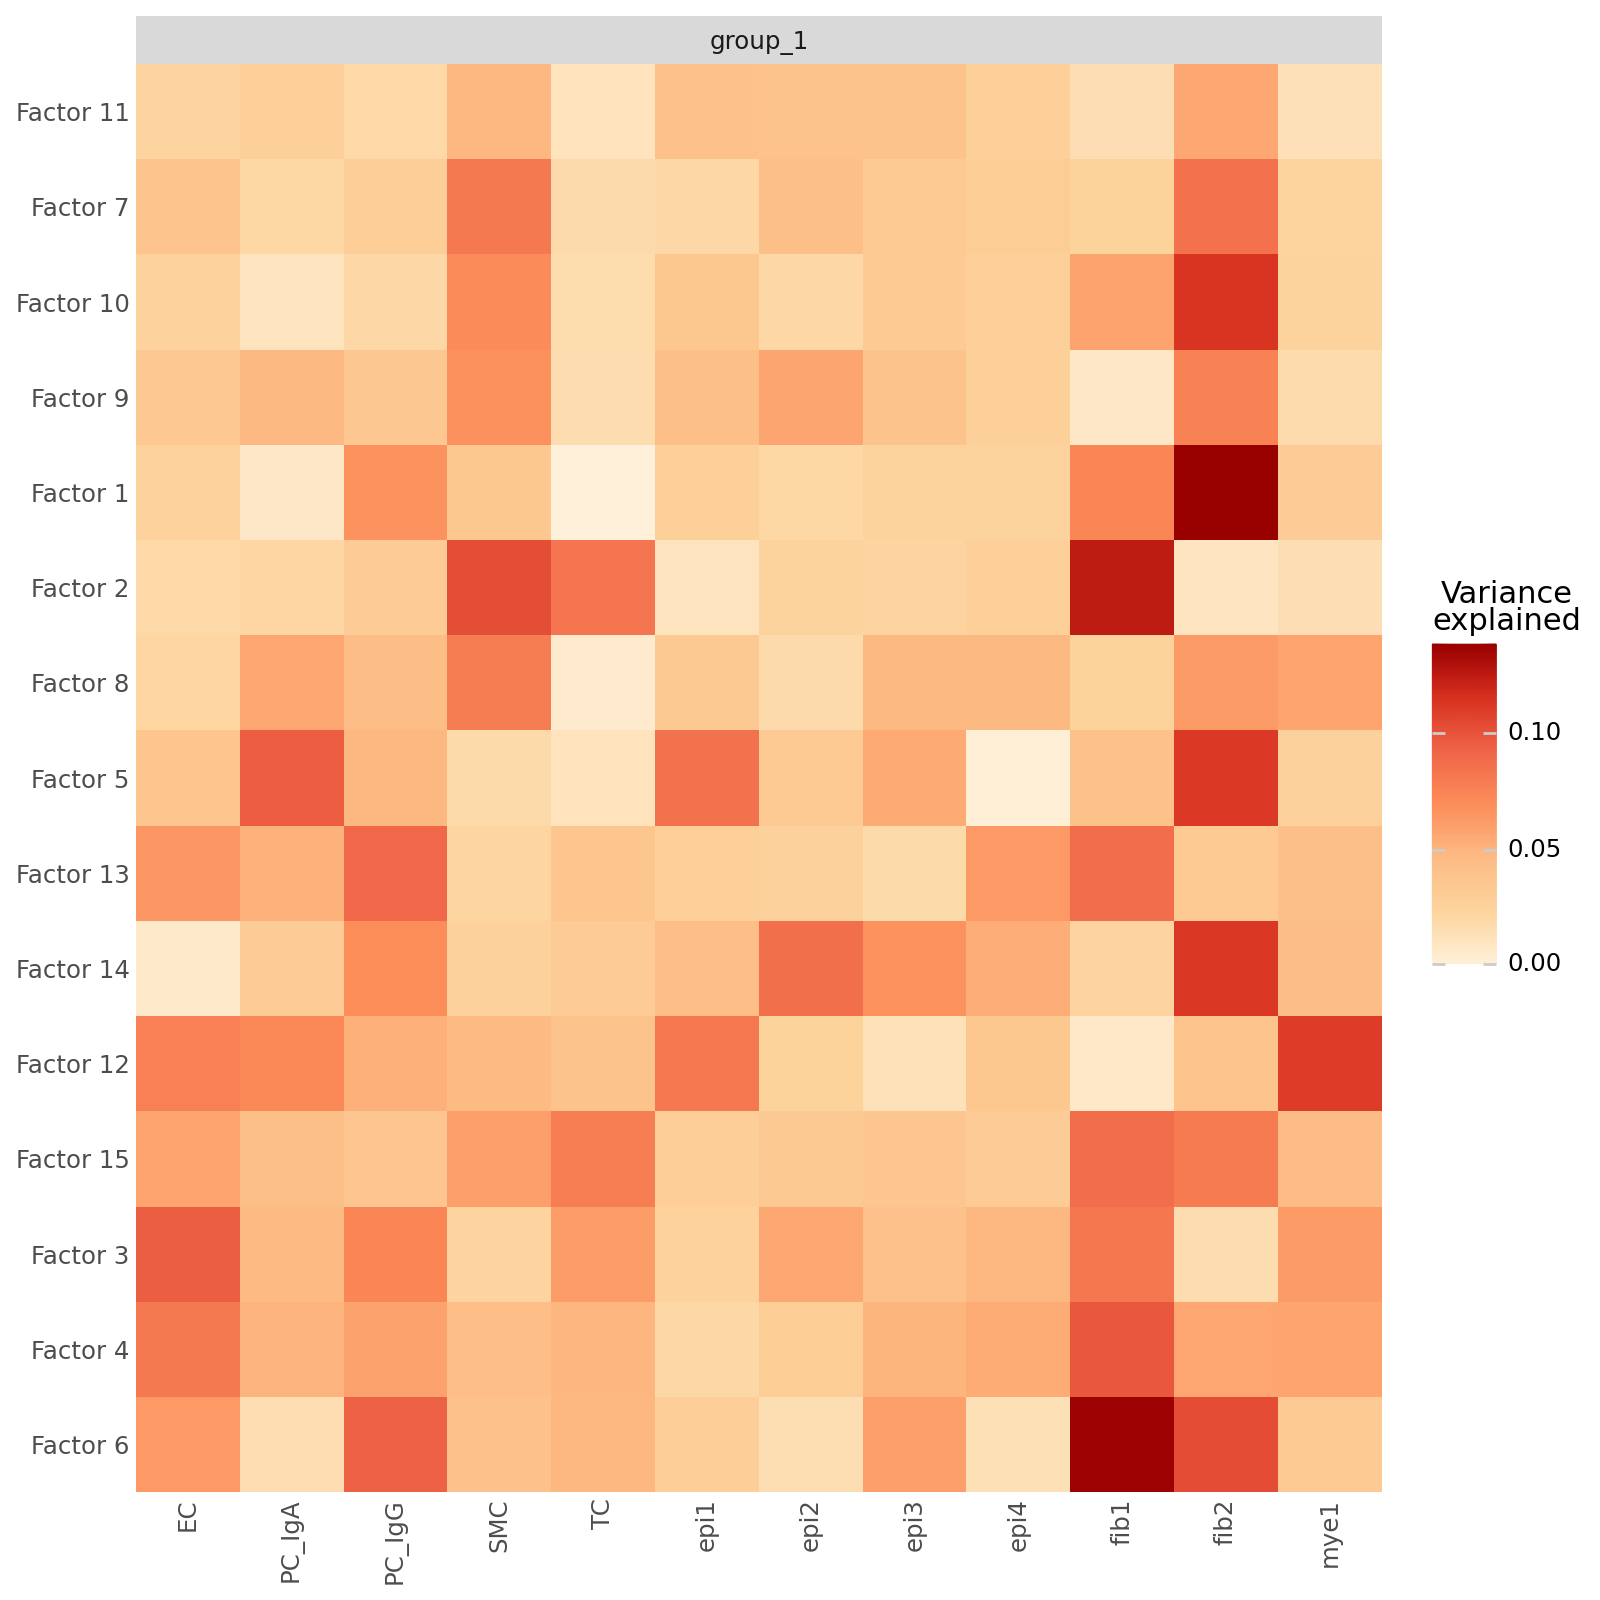

In [11]:
mfl.pl.variance_explained(model_ist, figsize= (8,8))

## Weights

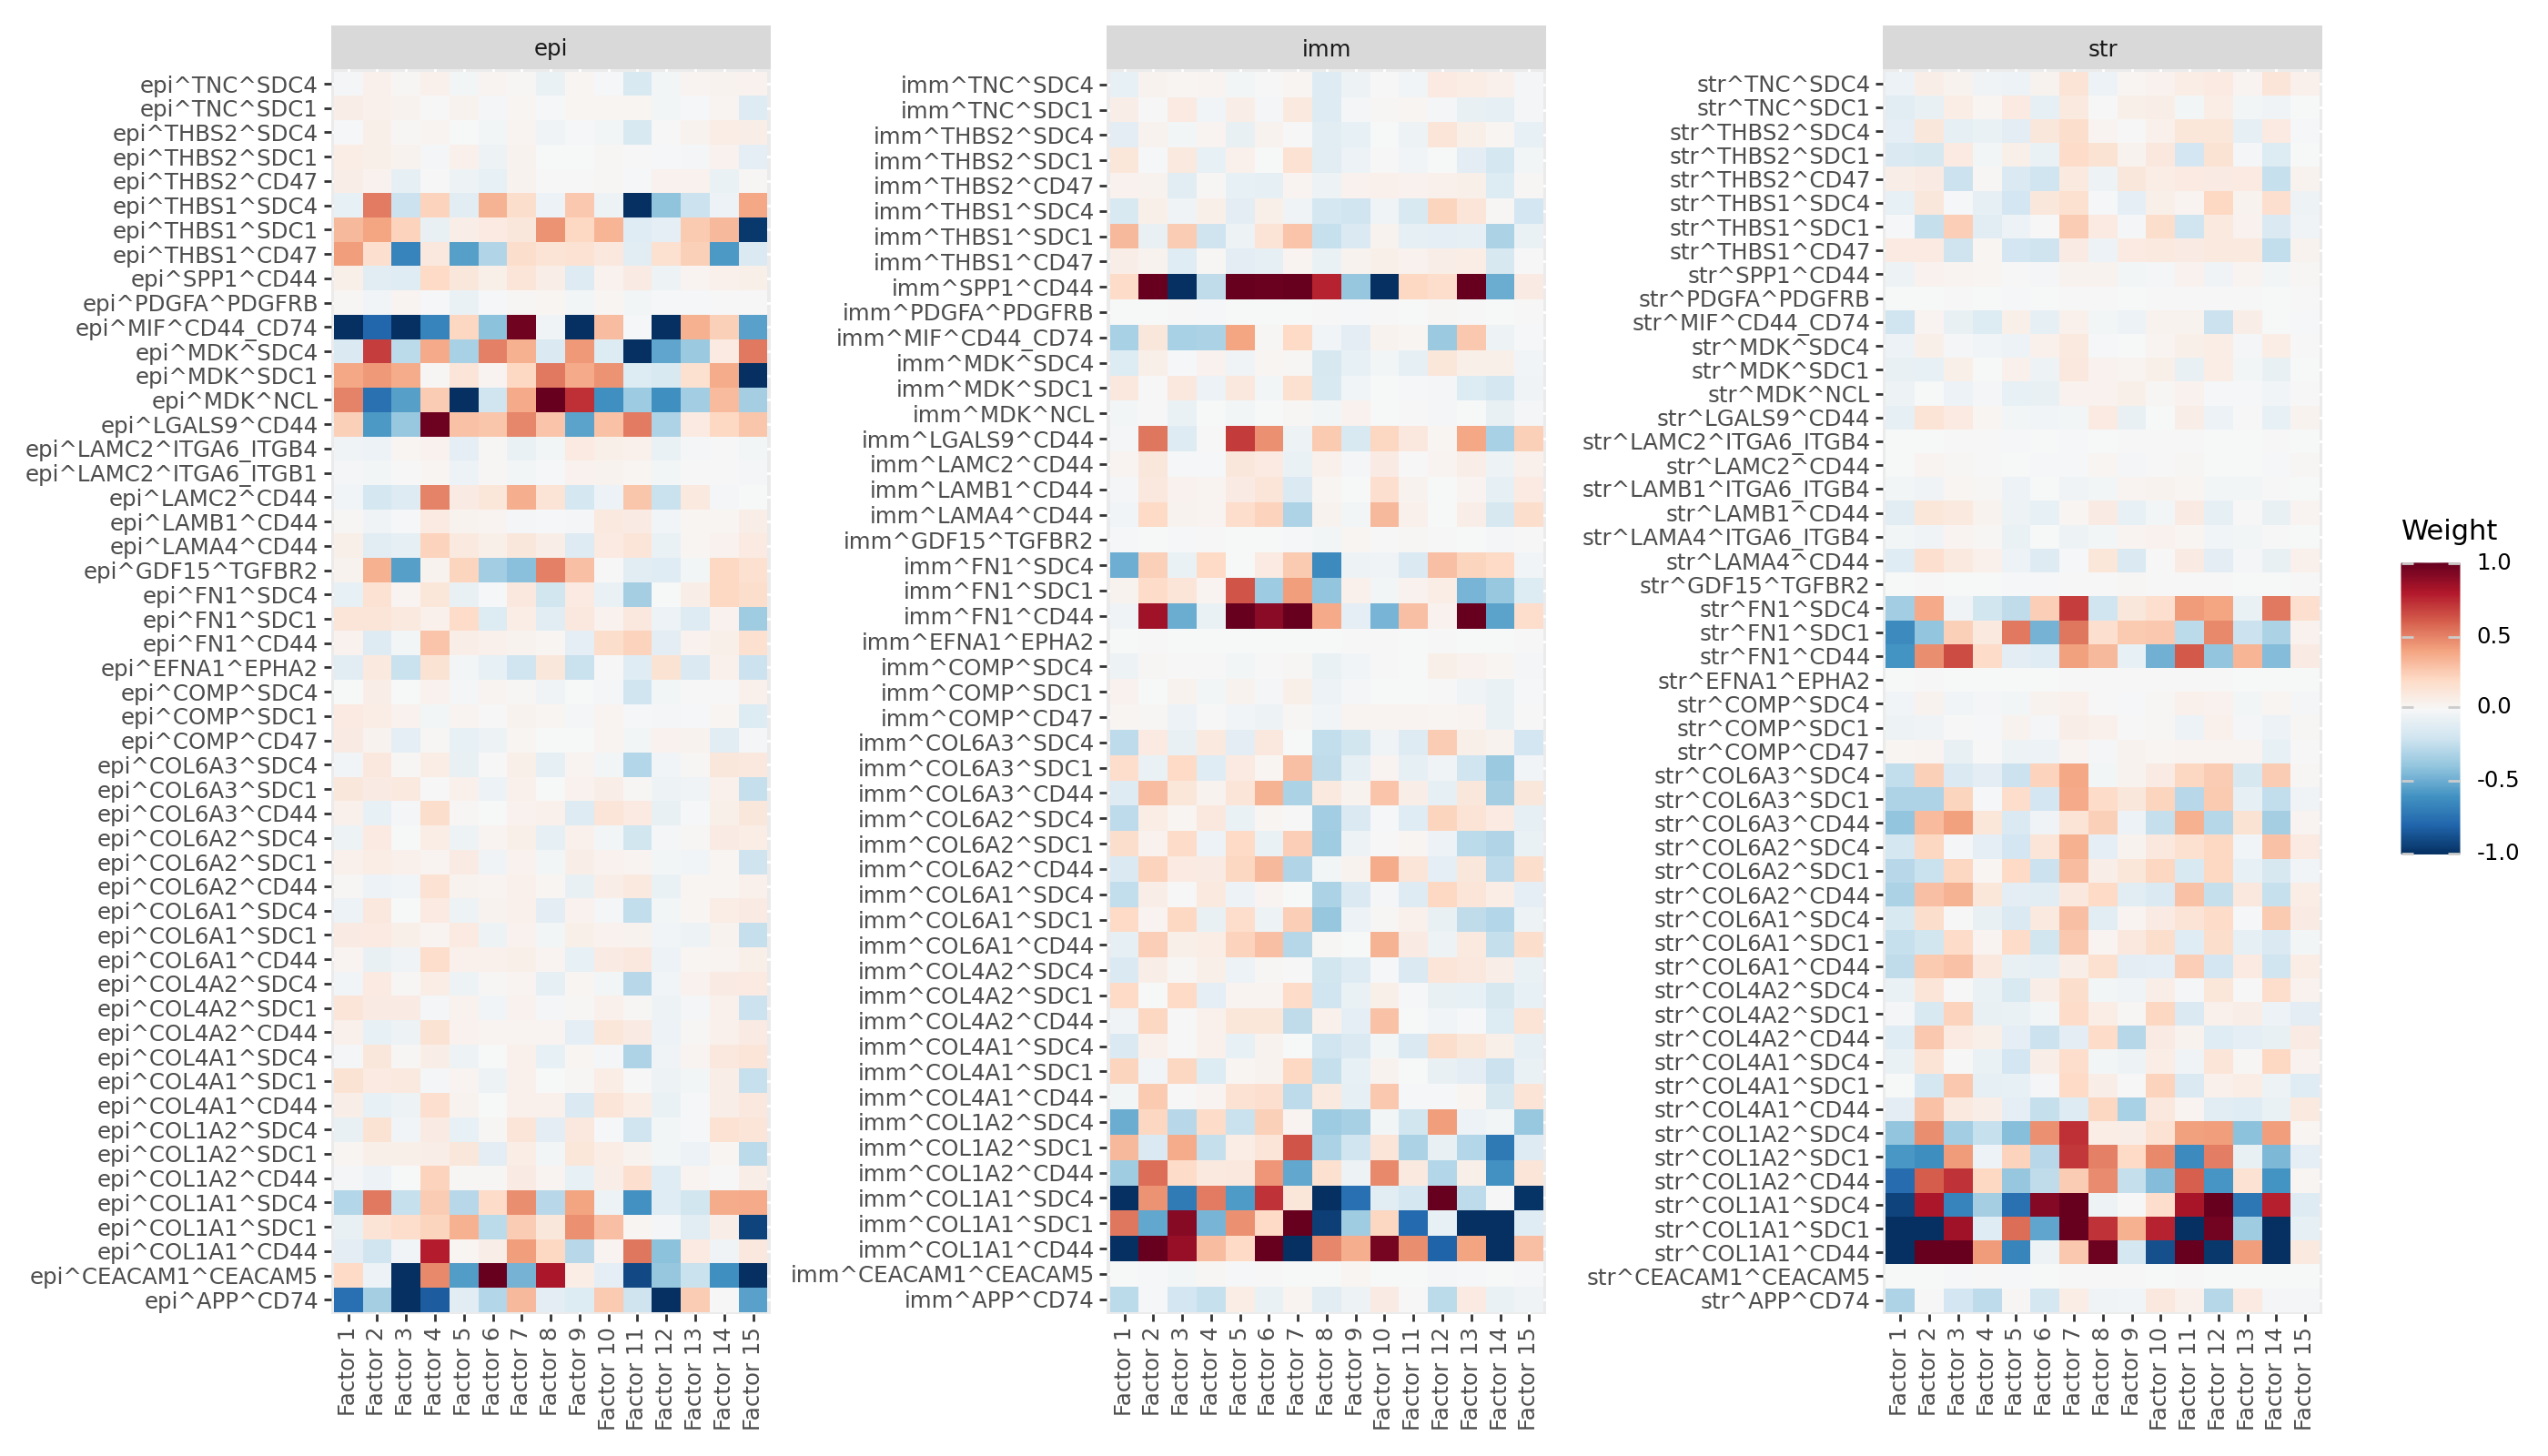

In [18]:
mfl.pl.all_weights(model_lv1, figsize=(14,8), show_featurenames=True)

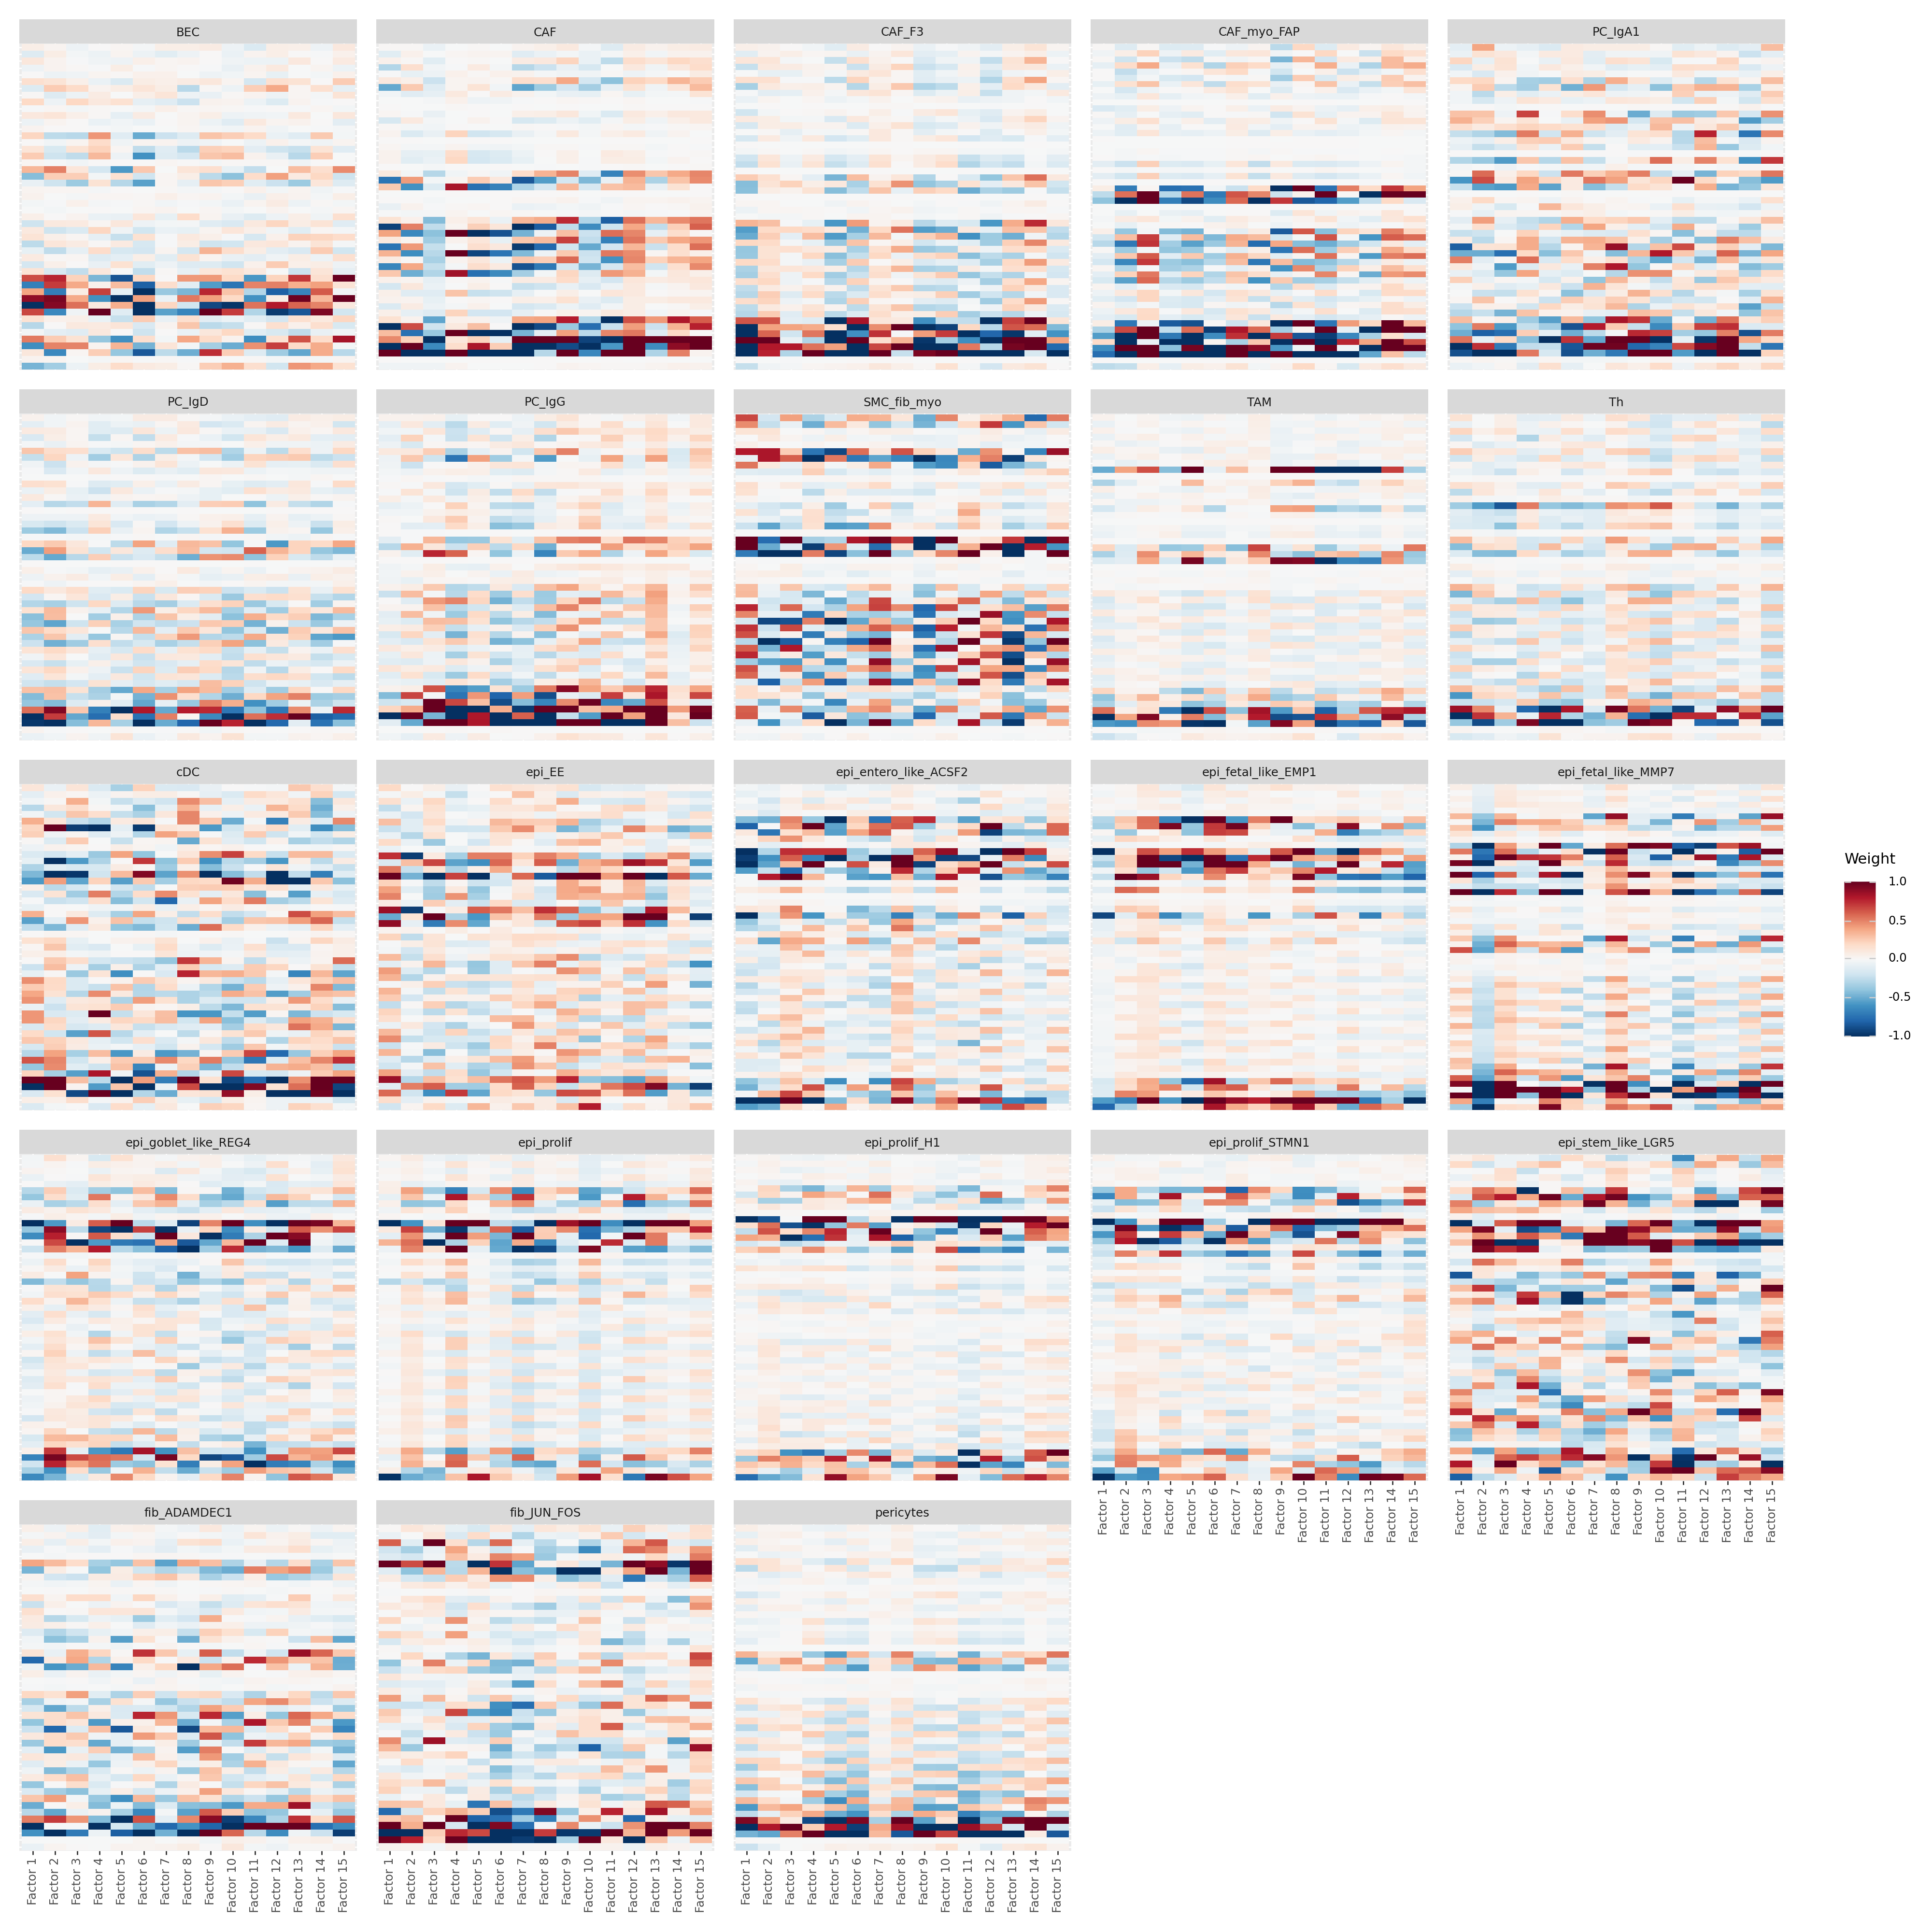

In [22]:
mfl.pl.all_weights(model_lv2, figsize=(20,20), show_featurenames=False)

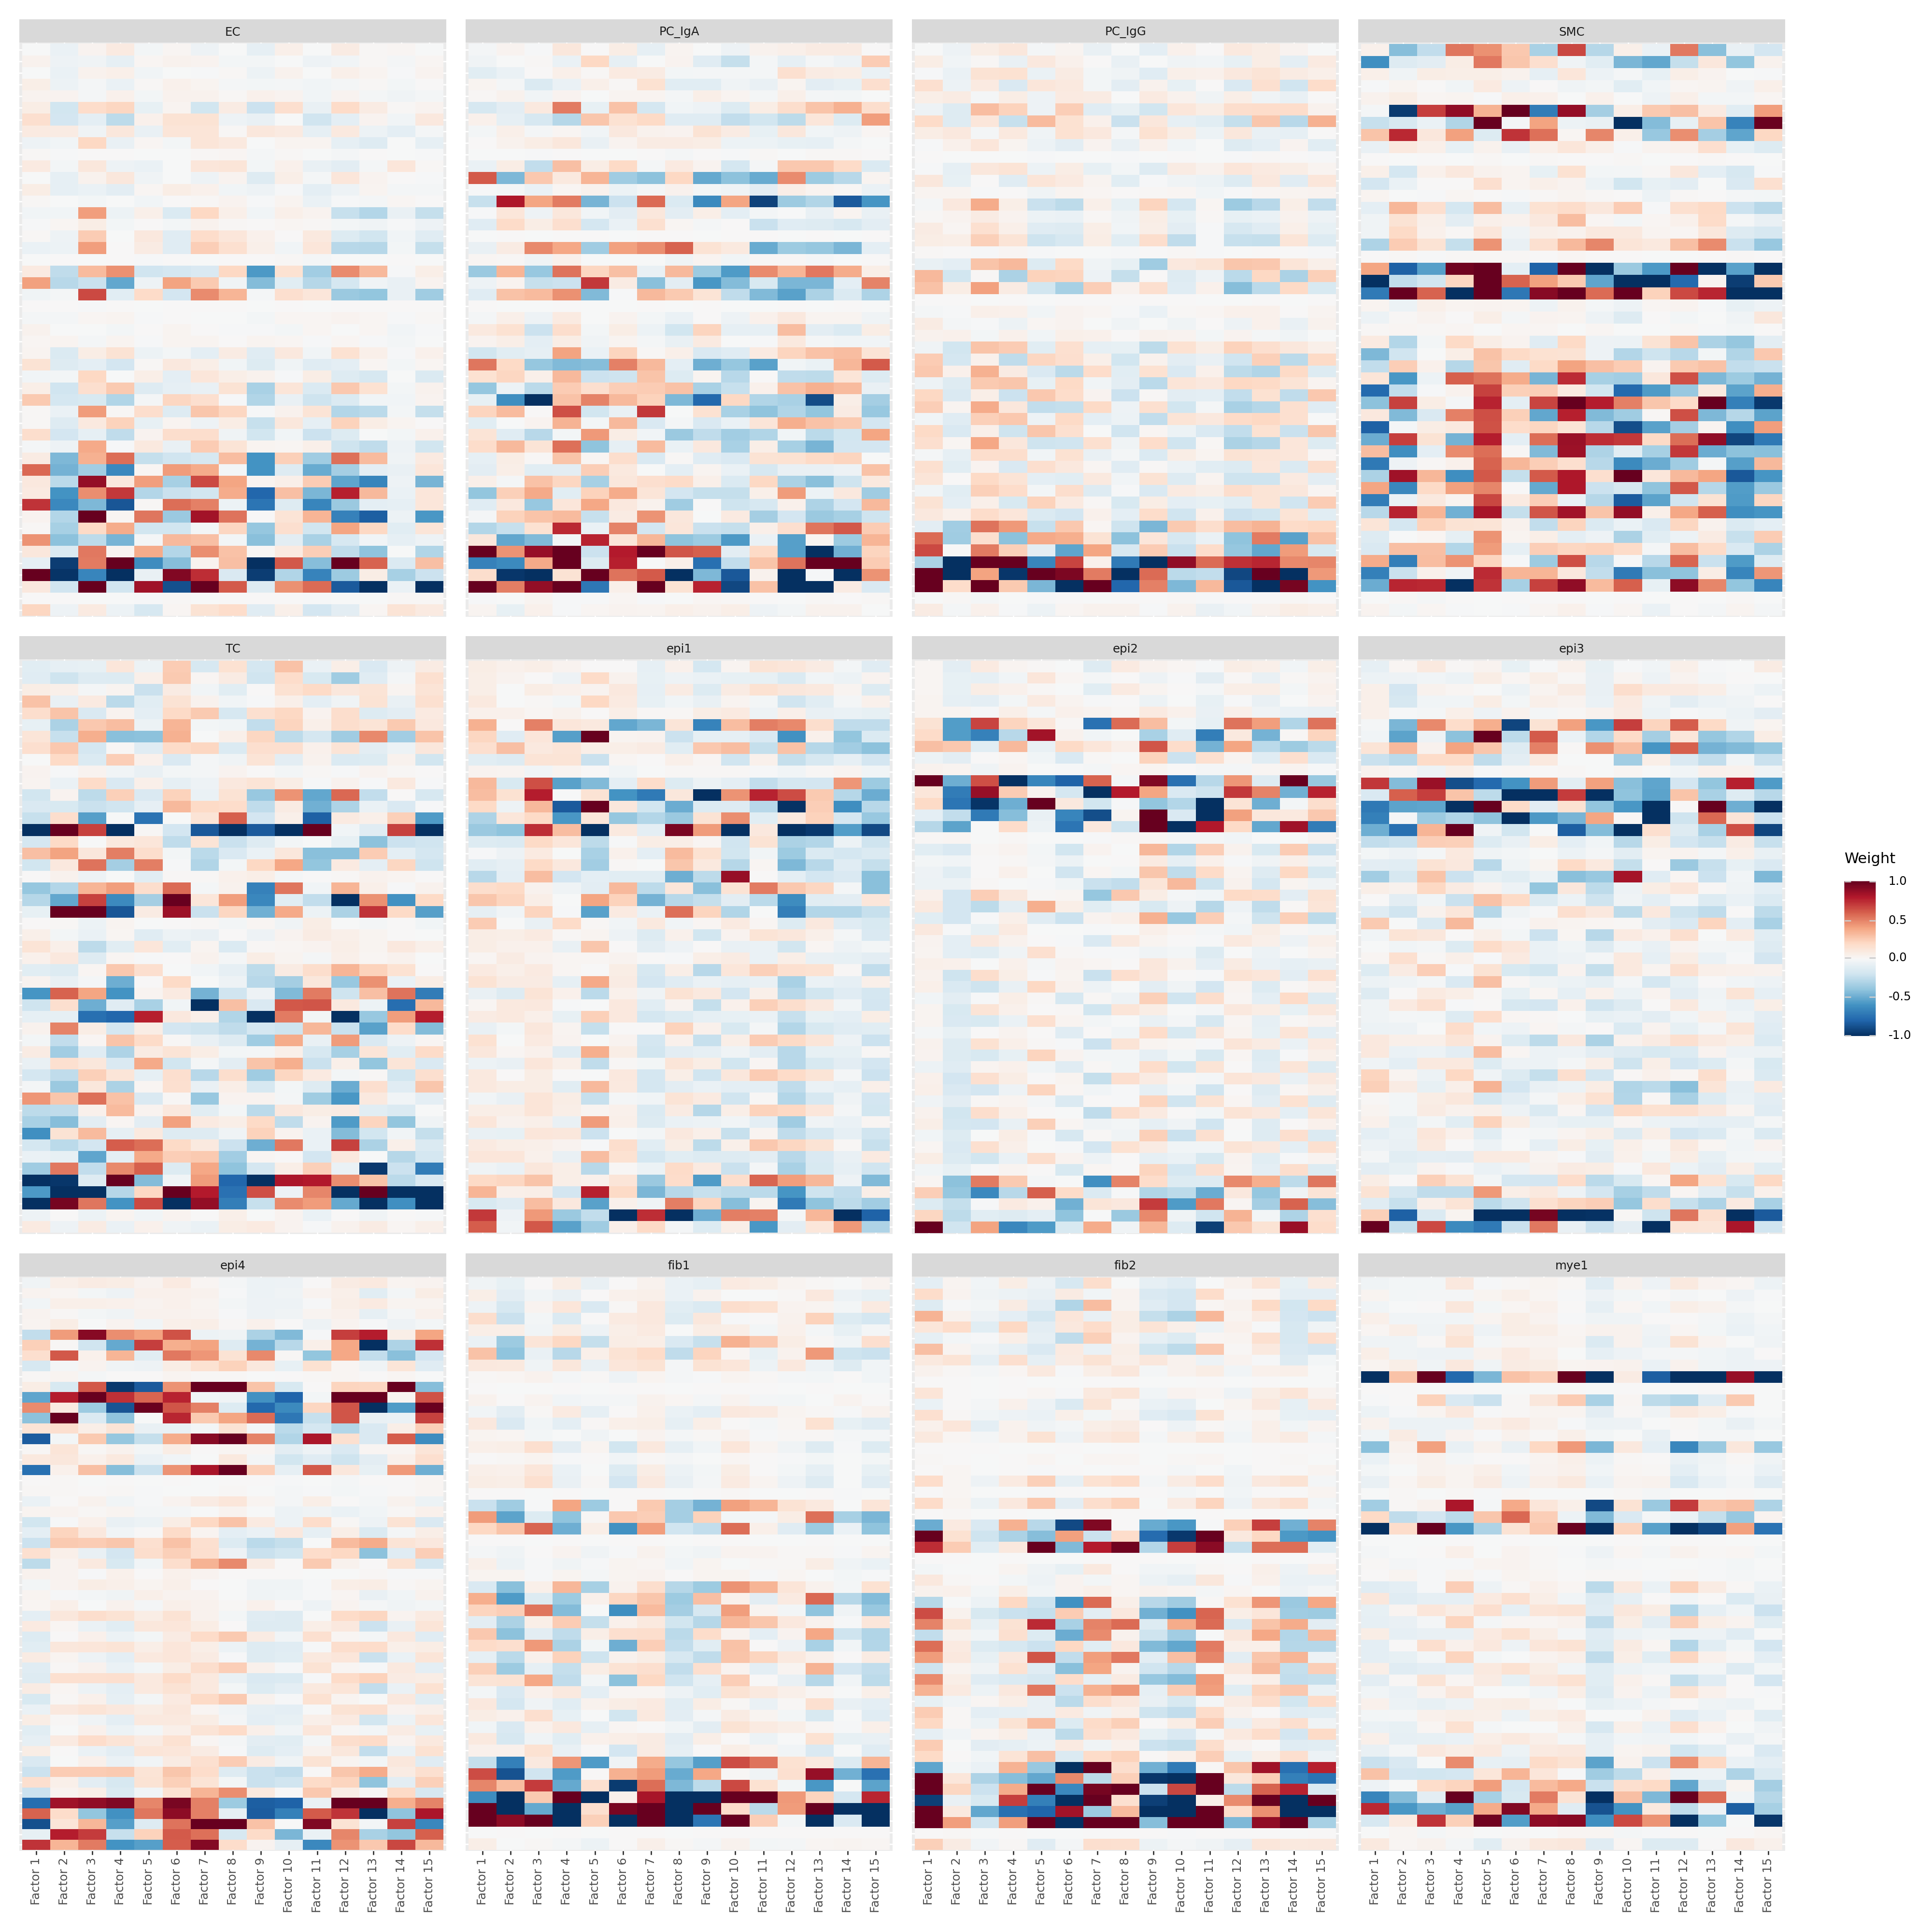

In [23]:
mfl.pl.all_weights(model_ist, figsize=(20,20), show_featurenames=False)

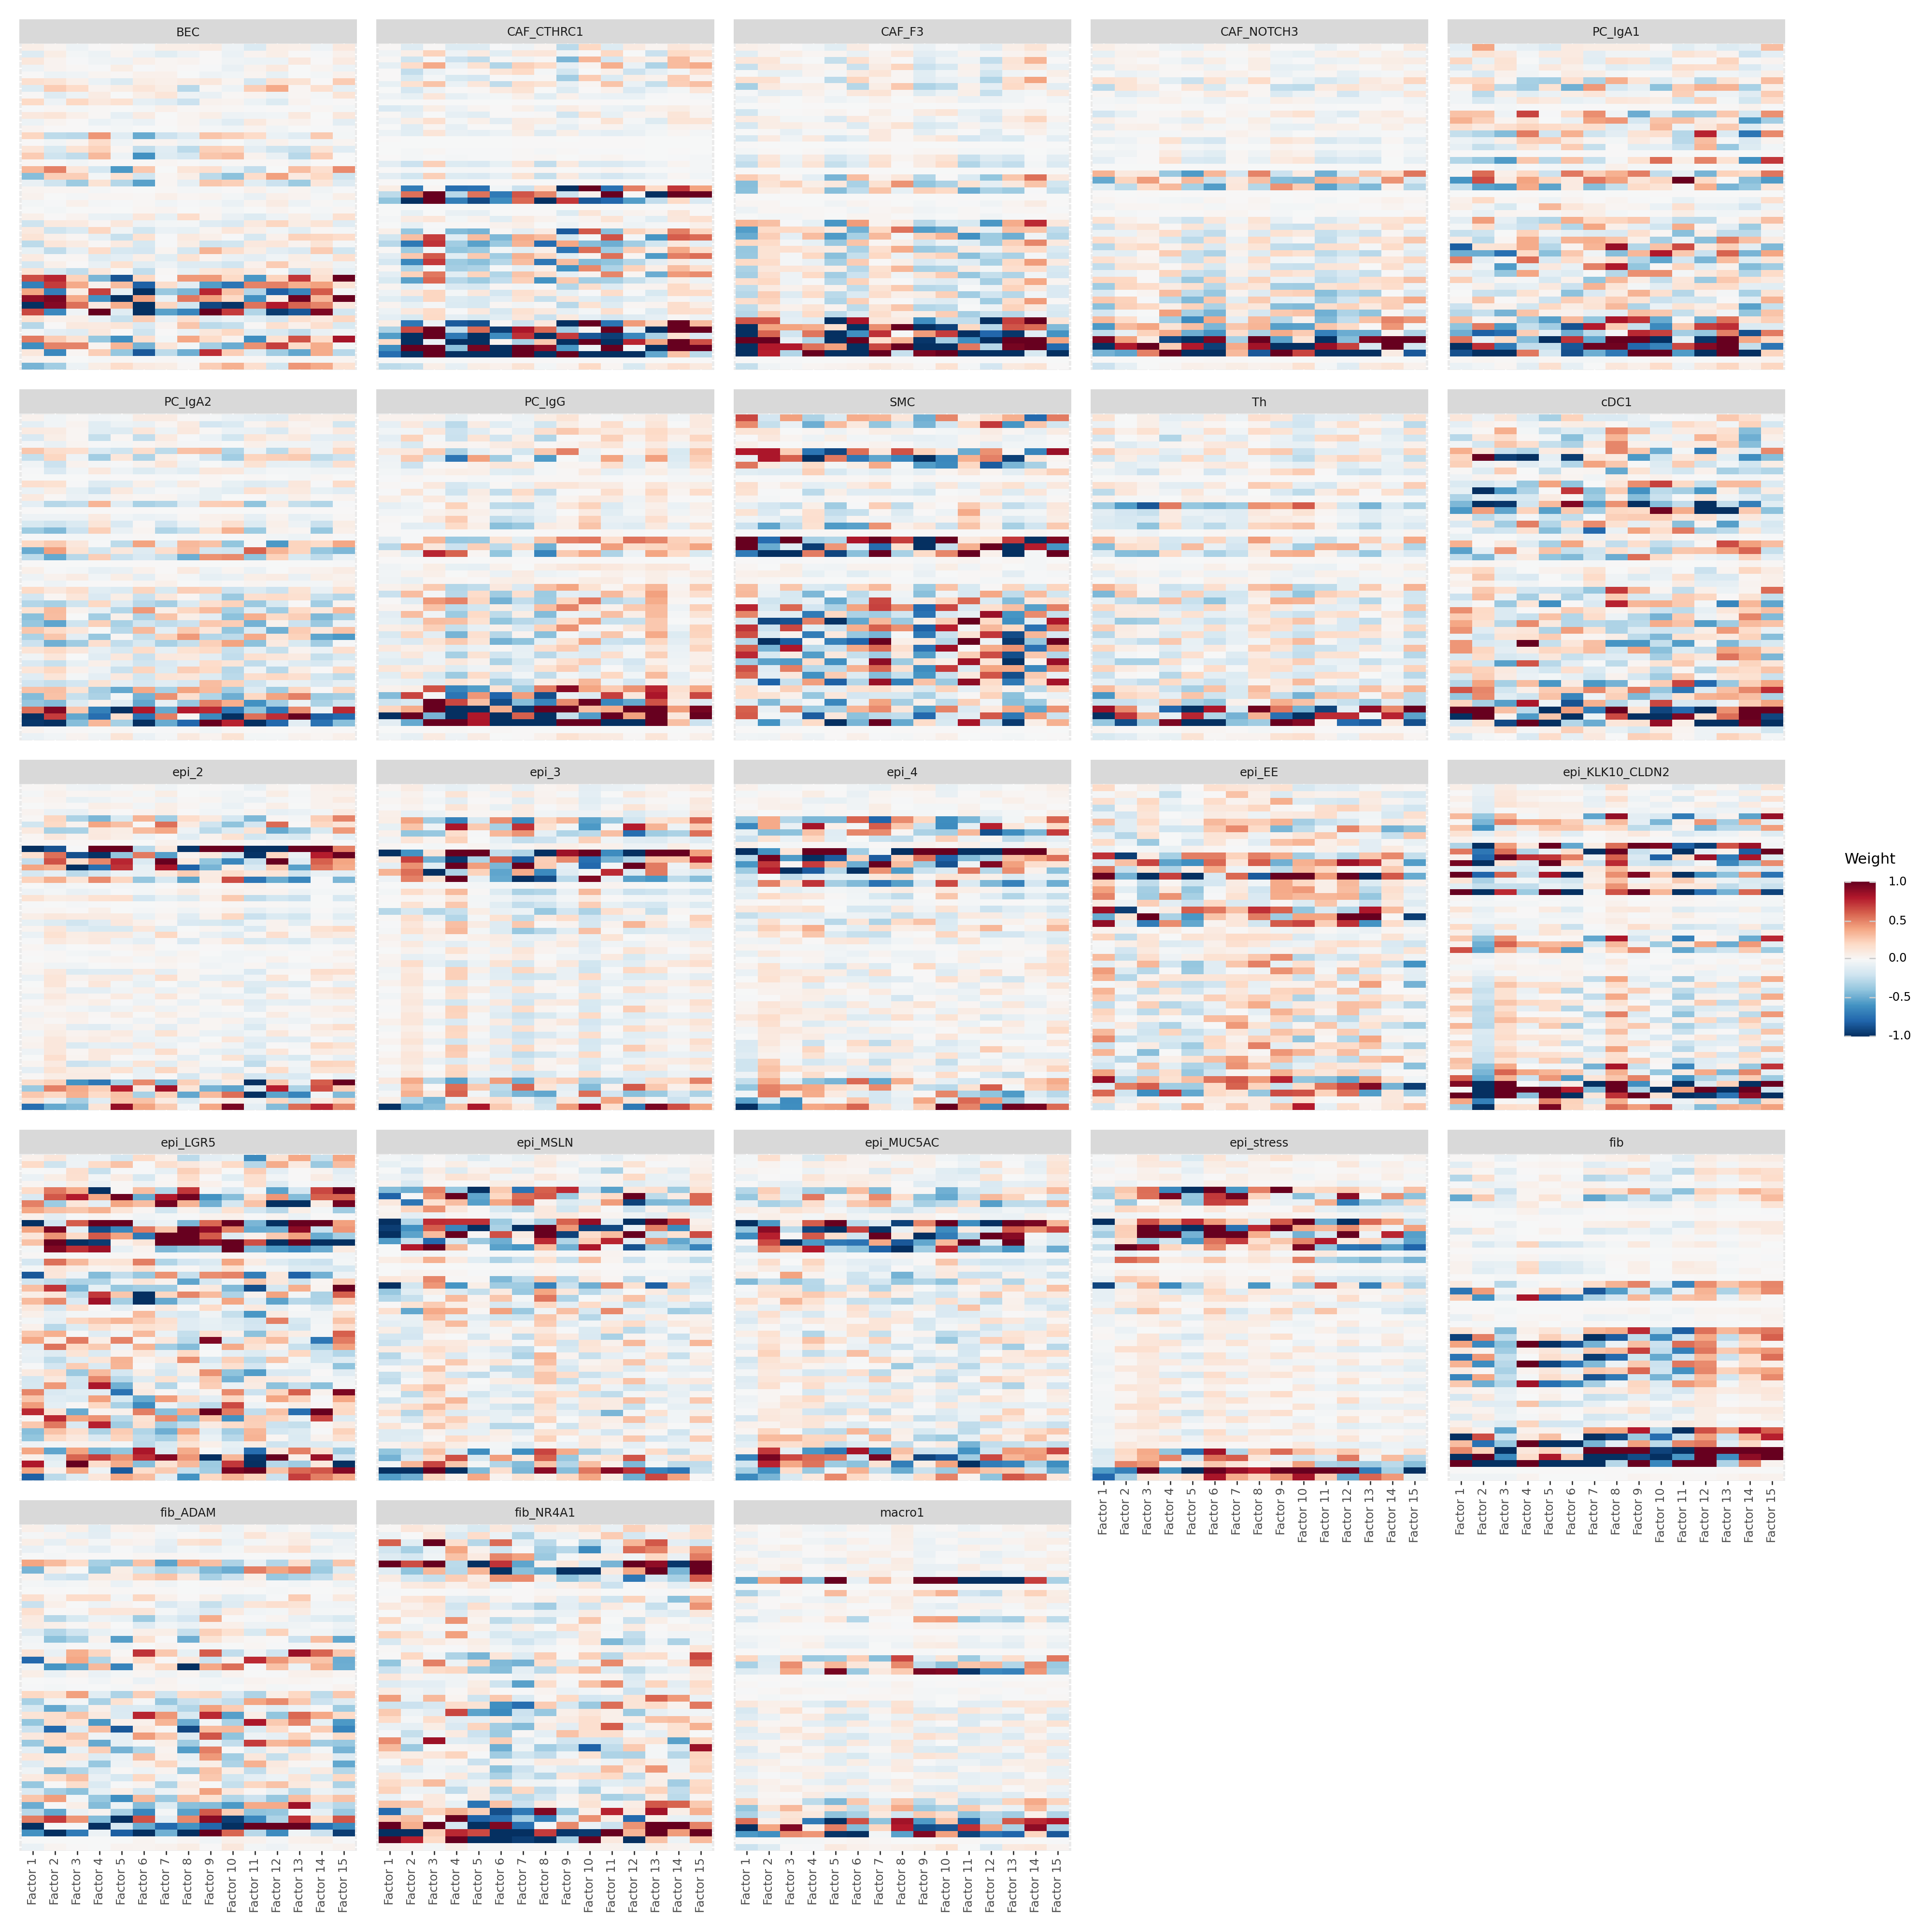

In [24]:
mfl.pl.all_weights(model_jst, figsize=(20,20), show_featurenames=False)